# Simulation of Laguerre-Gaussian beam on superconductors
- Edit by TTYeh (20240501) <br>

### Import modules to Colab
Execute the following 3 cells on CoLab environment for:
1. import modules to Colab
2. Check the GPU status
3. Mount the Google drive for saving file


In [1]:
# Automatically install tdgl from GitHub only if running in Google Colab
if "google.colab" in str(get_ipython()):
    %pip install --quiet git+https://github.com/loganbvh/py-tdgl.git
# %pip install pint==0.23

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 595.3/595.3 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 305.5/305.5 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 112.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 72.3 MB/s eta 0:00:00


In [ ]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"

### Check GPU
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

### Check memory
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

/bin/bash: line 1: nvidia-smi: command not found
Your runtime has 54.8 gigabytes of available RAM

You are using a high-RAM runtime!


In [2]:
from google.colab import drive
drive.mount('/content/drive')
# drive.flush_and_unmount()

Mounted at /content/drive


### Load function
The following codes work for both Colab environment and tdgl environment (Installation: https://py-tdgl.readthedocs.io/en/latest/) <br>
This section is for loading the revised functions (originally from Logan's code).

In [3]:
%config InlineBackend.figure_formats = {"retina", "png"}
Execute_GPU = True

import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.figsize"] = (7.5, 2.5)

import tdgl
# from tdgl.geometry import box, circle
# from tdgl.visualization.animate import create_animation
tdgl.SolverOptions.gpu = Execute_GPU # !!! Turn on GPU calculation !!!
from IPython.display import HTML, display
import h5py

import logging
import os
import shutil
from contextlib import nullcontext
from logging import Logger
from typing import Any, Dict, Literal, Optional, Sequence, Tuple, Union

from matplotlib import animation
from matplotlib import pyplot as plt
from tqdm import tqdm

from tdgl.device.device import Device
from tdgl.solution.data import get_data_range
from tdgl.visualization.common import DEFAULT_QUANTITIES, PLOT_DEFAULTS, Quantity, auto_grid
from tdgl.visualization.io import get_plot_data, get_state_string

def delete_files_in_directory(directory_path):
   try:
     files = os.listdir(directory_path)
     for file in files:
       file_path = os.path.join(directory_path, file)
       if os.path.isfile(file_path):
         os.remove(file_path)
     print("All files deleted successfully.")
   except OSError:
     print("Error occurred while deleting files.")

def create_animation_withEMwave(
    input_file: Union[str, h5py.File],
    *,
    output_file: Optional[str] = None,
    quantities: Union[str, Sequence[str]] = DEFAULT_QUANTITIES,
    shading: Literal["flat", "gouraud"] = "gouraud",
    fps: int = 30,
    dpi: float = 100,
    max_cols: int = 6,
    min_frame: int = 0,
    max_frame: int = -1,
    autoscale: bool = False,
    dimensionless: bool = False,
    xlim: Optional[Tuple[float, float]] = None,
    ylim: Optional[Tuple[float, float]] = None,
    axis_labels: bool = False,
    axes_off: bool = False,
    title_off: bool = False,
    full_title: bool = True,
    logger: Optional[Logger] = None,
    figure_kwargs: Optional[Dict[str, Any]] = None,
    writer: Union[str, animation.MovieWriter, None] = None,
    quiver_scale = 10,
    quiver_mesh_n = 20,
    width_quiver = 0.01,
) -> animation.FuncAnimation:
    """Generates, and optionally saves, and animation of a TDGL simulation.

    Args:
        input_file: An open h5py file or a path to an H5 file containing
            the :class:`tdgl.Solution` you would like to animate.
        output_file: A path to which to save the animation,
            e.g., as a gif or mp4 video.
        quantities: The names of the quantities to animate.
        shading: Shading method, "flat" or "gouraud". See matplotlib.pyplot.tripcolor.
        fps: Frame rate in frames per second.
        dpi: Resolution in dots per inch.
        max_cols: The maxiumum number of columns in the subplot grid.
        min_frame: The first frame of the animation.
        max_frame: The last frame of the animation.
        autoscale: Autoscale colorbar limits at each frame.
        dimensionless: Use dimensionless units for axes
        xlim: x-axis limits
        ylim: y-axis limits
        axes_off: Turn off the axes for each subplot.
        title_off: Turn off the figure suptitle.
        full_title: Include the full "state" for each frame in the figure suptitle.
        figure_kwargs: Keyword arguments passed to ``plt.subplots()`` when creating
            the figure.
        writer: A :class:`matplotlib.animation.MovieWriter` instance to use when
            saving the animation.
        logger: A logger instance to use.

    Returns:
        The animation as a :class:`matplotlib.animation.FuncAnimation`.
    """
    if isinstance(input_file, str):
        input_file = input_file
    if quantities is None:
        quantities = Quantity.get_keys()
    if isinstance(quantities, str):
        quantities = [quantities]
    quantities = [Quantity.from_key(name.upper()) for name in quantities]
    num_plots = len(quantities) +2 # Add two more subplots for E, Bz
    logger = logger or logging.getLogger()
    figure_kwargs = figure_kwargs or dict()
    figure_kwargs.setdefault("constrained_layout", True)
    default_figsize = (
        3.25 * min(max_cols, num_plots),
        2.5 * max(1, num_plots // max_cols),
    )
    figure_kwargs.setdefault("figsize", default_figsize)
    figure_kwargs.setdefault("sharex", True)
    figure_kwargs.setdefault("sharey", True)

    logger.info(f"Creating animation for {[obs.name for obs in quantities]!r}.")

    mpl_context = nullcontext() if output_file is None else plt.ioff()
    if isinstance(input_file, str):
        h5_context = h5py.File(input_file, "r")
    else:
        h5_context = nullcontext(input_file)

    with h5_context as h5file:
        with mpl_context:
            device = Device.from_hdf5(h5file["solution/device"])
            mesh = device.mesh
            if dimensionless:
                scale = 1
                units_str = "\\xi"
            else:
                scale = device.layer.coherence_length
                units_str = f"{device.ureg(device.length_units).units:~L}"
            x, y = scale * mesh.sites.T

            # Get the ranges for the frame
            _min_frame, _max_frame = get_data_range(h5file)
            min_frame = max(min_frame, _min_frame)
            if max_frame == -1:
                max_frame = _max_frame
            else:
                max_frame = min(max_frame, _max_frame)

            # Temp data to use in plots
            temp_value = np.ones(len(mesh.sites), dtype=float)
            temp_value[0] = 0
            temp_value[1] = 0.5

            fig, axes = auto_grid(num_plots, max_cols=max_cols, **figure_kwargs)
            collections = []
            quantities.append('E') # Add one more quantities
            # quantities.append('Bz') # Add one more quantities
            X = np.linspace(-width/2,width/2,quiver_mesh_n)
            Y = np.linspace(-height/2,height/2,quiver_mesh_n)
            Xv, Yv = np.meshgrid(X, Y)
            ti = dict(input_file['data'][str(1)].attrs)['time']
            E_x, E_y = E_input_frame(Xv,Yv,ti,take_real=False)
            B_x, B_y, B_z = E2Bv(Xv,Yv,E0i*E_x,E0i*E_y,constant_Bz,c,w_input)
            Bzmax, Bzmin = [find_max_Bz(Xv,Yv,E0i,constant_Bz,c,w_input), -find_max_Bz(Xv,Yv,E0i,constant_Bz,c,w_input)]

            for quantity, ax in zip(quantities, axes.flat):
                ax: plt.Axes
                if quantity!='E' and quantity!='Bz':
                    opts = PLOT_DEFAULTS[quantity]
                    collection = ax.tripcolor(
                        x,
                        y,
                        temp_value,
                        triangles=mesh.elements,
                        shading=shading,
                        cmap=opts.cmap,
                        vmin=opts.vmin,
                        vmax=opts.vmax,
                    )
                    cbar = fig.colorbar(collection, ax=ax)
                    cbar.set_label(opts.clabel)
                    ax.set_aspect("equal")
                    ax.set_title(quantity.value)
                    ax.set_xlim(xlim)
                    ax.set_ylim(ylim)
                    if axes_off:
                        ax.axis("off")
                    if axis_labels:
                        ax.set_xlabel(f"$x$ [${units_str}$]")
                        ax.set_ylabel(f"$y$ [${units_str}$]")
                    collections.append(collection)

                if quantity=='E': # For new plot: "E"
                    collection = ax.quiver(
                        Xv,
                        Yv,
                        np.real(E_x),
                        np.real(E_y),
                        scale=quiver_scale,
                        scale_units='x',
                        width=width_quiver*abs(X[2]-X[1]),
                    )
                    ax.set_aspect("equal")
                    ax.set_title('$E$')
                    ax.set_xlim(xlim)
                    ax.set_ylim(ylim)
                    if axes_off:
                        ax.axis("off")
                    if axis_labels:
                        ax.set_xlabel(f"$x$ [${units_str}$]")
                        ax.set_ylabel(f"$y$ [${units_str}$]")
                    collections.append(collection)
                # if quantity=='Bz': # For new plot: "Bz"
                #     collection = ax.pcolormesh(
                #         X,
                #         Y,
                #         np.real(B_z),
                #         cmap="PRGn",
                #         shading='gouraud',
                #         vmin=Bzmin,
                #         vmax=Bzmax,
                #     )
                #     cbar = plt.colorbar(collection)
                #     cbar.set_label('$B_{z}$ ['+field_units+']')
                #     ax.set_aspect("equal")
                #     ax.set_title('$B_{z}$ ')
                #     ax.set_xlim(xlim)
                #     ax.set_ylim(ylim)
                #     if axes_off:
                #         ax.axis("off")
                #     if axis_labels:
                #         ax.set_xlabel(f"$x$ [${units_str}$]")
                #         ax.set_ylabel(f"$y$ [${units_str}$]")
                #     collections.append(collection)
            vmins = [+np.inf for _ in quantities]
            vmaxs = [-np.inf for _ in quantities]

            def update(frame):
                if not h5file:
                    return
                frame += min_frame
                state = get_state_string(h5file, frame, max_frame)
                if not full_title:
                    state = state.split(",")[0]
                if not title_off:
                    fig.suptitle(state)

                ti = dict(input_file['data'][str(frame)].attrs)['time']
                E_x, E_y = E_input_frame(Xv,Yv,ti,take_real=False)
                B_x, B_y, B_z = E2Bv(Xv,Yv,E0i*E_x,E0i*E_y,constant_Bz,c,w_input)

                for i, (quantity, collection) in enumerate(
                    zip(quantities, collections)
                ):
                    if quantity!='E' and quantity!='Bz':
                        opts = PLOT_DEFAULTS[quantity]
                        values, direction, _ = get_plot_data(h5file, mesh, quantity, frame)
                        mask = np.abs(values - np.mean(values)) <= 6 * np.std(values)
                        if opts.vmin is None:
                            if autoscale:
                                vmins[i] = np.min(values[mask])
                            else:
                                vmins[i] = min(vmins[i], np.min(values[mask]))
                        else:
                            vmins[i] = opts.vmin
                        if opts.vmax is None:
                            if autoscale:
                                vmaxs[i] = np.max(values[mask])
                            else:
                                vmaxs[i] = max(vmaxs[i], np.max(values[mask]))
                        else:
                            vmaxs[i] = opts.vmax
                        if opts.symmetric:
                            vmax = max(abs(vmins[i]), abs(vmaxs[i]))
                            vmaxs[i] = vmax
                            vmins[i] = -vmax
                        if shading == "flat":
                            # https://stackoverflow.com/questions/40492511/set-array-in-tripcolor-bug
                            values = values[mesh.elements].mean(axis=1)
                        collection.set_array(values)
                        collection.set_clim(vmins[i], vmaxs[i])
                    if quantity=='E':
                        collection.set_UVC(np.real(E_x),np.real(E_y))
                    # if quantity=='Bz':
                    #     collection.set_array(np.real(B_z))
                    #     collection.set_clim(Bzmin, Bzmax)
                fig.canvas.draw()

            anim = animation.FuncAnimation(
                fig,
                update,
                frames=max_frame - min_frame,
                interval=1e3 / fps,
                blit=False,
            )

        if output_file is not None:
            output_file = os.path.join(os.getcwd(), output_file)
            if writer is None:
                kwargs = dict(fps=fps)
            else:
                kwargs = dict(writer=writer)
            fname = os.path.basename(output_file)
            with tqdm(
                total=len(range(min_frame, max_frame)),
                unit="frames",
                desc=f"Saving to {fname}",
            ) as pbar:
                anim.save(
                    output_file,
                    dpi=dpi,
                    progress_callback=lambda frame, total: pbar.update(1),
                    **kwargs,
                )

        return anim

def make_video_from_solution(
    solution,
    quantities=("order_parameter", "phase"),
    fps=20,
    figsize=(5, 4),
    output_file='None',
    dpi=100,
    quiver_scale=10,
    quiver_mesh_n=20,
    width_quiver=0.01,
):
    """Generates an HTML5 video from a tdgl.Solution."""

    with tdgl.non_gui_backend():
        with h5py.File(solution.path, "r") as h5file:
            anim = create_animation_withEMwave(
                h5file,
                quantities=quantities,
                fps=fps,
                figure_kwargs=dict(figsize=figsize),
                axis_labels = True,
                output_file=output_file,
                dpi=dpi,
                quiver_scale=quiver_scale,
                quiver_mesh_n=quiver_mesh_n,
                width_quiver=width_quiver,
            )
            video = anim.to_html5_video()
        return HTML(video)

MAKE_ANIMATIONS = True
# MAKE_ANIMATIONS = False
""" Done."""

/usr/local/lib/python3.12/dist-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


' Done.'

## Trace of Letter (from A to Z)

In [4]:
# Ref of letters:
# https://pythondex.com/draw-letters-in-python-turtle

class LaserTrace:

    def __init__(self,stepsize=1,inipos=[0,0],velocity:float=1.0):
        self.stepsize = stepsize
        self.index = np.array([0])
        self.trace = np.zeros([2,1])
        self.trace[:,0] = np.array(inipos)
        self.velocity = velocity
        self.timestep = self.index*stepsize/velocity
        self.laser_intensity = np.ones_like(self.index)
        self.pen = 0
        self.heading = 0
        self.center = inipos

    def goto(self,position_x,position_y):
        distance = np.sqrt((position_x-self.trace[0,-1])**2+(position_y-self.trace[1,-1])**2)
        d_steps = int(abs(distance))
        append_pos = np.zeros([2,d_steps])
        append_pos[0,:] = (np.arange(d_steps)+1)/d_steps*position_x + (1-(np.arange(d_steps)+1)/d_steps)*self.trace[0,-1]
        append_pos[1,:] = (np.arange(d_steps)+1)/d_steps*position_y + (1-(np.arange(d_steps)+1)/d_steps)*self.trace[1,-1]
        self._append(d_steps,append_pos,self.pen)

    def setpos(self,position_x,position_y):
        position = [position_x+self.center[0]*0,position_y+self.center[1]*0]
        self.index = np.append(self.index,self.index[-1]+1)
        self.trace = np.insert(self.trace,len(self.trace.T),np.array(position),axis=1)
        self.timestep = self.index*self.stepsize/self.velocity
        self.laser_intensity = np.append(self.laser_intensity,self.pen)

    def _append(self,steps,append_pos,laser_intensity):
        self.index = np.append(self.index,np.arange(self.index[-1]+1,self.index[-1]+1+steps))
        self.trace = np.append(self.trace,append_pos,axis=1)
        self.timestep = self.index*self.stepsize/self.velocity
        self.laser_intensity = np.append(self.laser_intensity,np.ones(steps)*laser_intensity)

    def delay(self,delaytime):
        d_t = self.stepsize/self.velocity
        t_steps = int(delaytime/d_t)
        append_pos = np.ones([2,t_steps],dtype=float)
        append_pos[0,:] = append_pos[0,:]*self.trace[0,-1]
        append_pos[1,:] = append_pos[1,:]*self.trace[1,-1]
        self._append(t_steps,append_pos,self.pen)

    def _orient(self):
        return np.array([np.cos(self.heading/360*2*np.pi), np.sin(self.heading/360*2*np.pi)])

    def _rotate(self,rotate_angle):
        self.heading += rotate_angle

    def _go(self,distance):
        """Move object forward by specified distance"""
        d_steps = int(abs(distance))
        append_pos = np.outer(self.trace[:,-1],np.ones(d_steps)) + np.outer(self._orient(),self.stepsize*np.sign(distance)*np.arange(d_steps))
        self._append(d_steps,append_pos,self.pen)

    def penup(self):
        self.pen = 0

    def pendown(self):
        self.pen = 1

    def right(self,angle):
        """Turn object counterclockwise by specified angle if angle > 0."""
        self._rotate(-angle)

    def left(self,angle):
        """Turn object clockwise by specified angle if angle > 0."""
        self._rotate(angle)

    def forward(self, distance):
        """Move the object forward by the specified distance."""
        self._go(distance)

    def backward(self, distance):
        """Move the object backward by the specified distance."""
        self._go(-distance)

    def circle(self, radius, extent=None, steps=100):
        if extent==None: extent=360
        r_steps = (np.arange(steps)*extent/steps+self.heading)/360*2*np.pi
        pos_x = radius*np.sin(r_steps)
        pos_y = radius*np.cos(r_steps)
        append_pos = np.zeros([2,steps])
        append_pos[0,:] = self.trace[0,-1] - (pos_x-pos_x[0])
        append_pos[1,:] = self.trace[1,-1] - (pos_y-pos_y[0])
        self._append(steps,append_pos,self.pen)
        dx = append_pos[0,-1]-append_pos[0,-2]
        dy = append_pos[1,-1]-append_pos[1,-2]
        self.heading = self.heading+extent


# Reference: https://pythondex.com/draw-letters-in-python-turtle
# Quicktest: https://projects.raspberrypi.org/en/projects/generic-python-turtle-write

class WriteSingleLetter:

    def __init__(self,width=1,height=1,center=[0,0],velocity:float=1.0):
        self.width = width
        self.height = height
        self.center = center
        self.velocity = velocity
        self.trace = []
        self.index = []
        self.timestep = []
        self.laser_intensity = []
        self.pen = 0

    def _AlignTrace(self):
        self.trace[0,0], self.trace[1,0] = np.copy(self.trace[0,1]), np.copy(self.trace[1,1])
        if self.LetterHWR>0.01: self.trace[0,:] = self.trace[0,:]/(max(self.trace[0,:])-min(self.trace[0,:]))*(max(self.trace[1,:])-min(self.trace[1,:]))*self.LetterHWR
        self.trace[0,:] = self.trace[0,:]/(max(self.trace[1,:])-min(self.trace[1,:]))*self.width # Rescale with height to prevent the letter like "I"
        self.trace[1,:] = self.trace[1,:]/(max(self.trace[1,:])-min(self.trace[1,:]))*self.height
        self.trace[0,:] = self.trace[0,:]-min(self.trace[0,:])+self.center[0]-self.LetterHWR*self.width/2
        self.trace[1,:] = self.trace[1,:]-min(self.trace[1,:])+self.center[1]-self.height/2

    def _CopyTrace(self,t,realign=True):
        self.trace = np.copy(t.trace)
        self.index = np.copy(t.index)
        self.timestep = np.copy(t.timestep)
        self.laser_intensity = np.copy(t.laser_intensity)
        if realign: self._AlignTrace()

    global ratio1, ratio2, ratio3
    ratio1, ratio2, ratio3 = 0.8, 0.4, 0

    def A(self):
        t = LaserTrace()
        t.penup()
        t.setpos(-30,50) #centering in the screen
        t.pendown()
        t.right(65)
        t.forward(100)
        t.setpos(-30,50)
        t.right(50)
        t.forward(100)
        t.penup()
        t.setpos(-55,-10)
        t.right(65)
        t.pendown()
        t.backward(50)
        t.penup()
        self.LetterHWR = ratio1
        self._CopyTrace(t)

    def B(self):
        t = LaserTrace()
        t.penup()
        t.setpos(-30,50) #centering in the screen
        t.pendown()
        t.right(90)
        t.forward(200)
        t.penup()
        t.setpos(-30,50) #centering in the screen
        #draw first curve
        t.pendown()
        t.right(-90)
        t.circle(-50,180,300)
        t.penup()
        t.goto(-30,-50) #centering in the screen
        #draw second curve
        t.pendown()
        t.right(180)
        t.circle(-50,180,300)
        t.penup()
        self.LetterHWR = ratio1
        self._CopyTrace(t)

    def C(self):
        t = LaserTrace()
        t.penup()
        #draw straight line
        t.setpos(-30,50) #centering in the screen
        t.pendown()
        t.right(180)
        t.circle(50,-180,200)
        t.penup()
        self.LetterHWR = ratio1
        self._CopyTrace(t)

    def D(self):
        t = LaserTrace()
        t.penup()
        #draw straight line
        t.setpos(-30,50) #centering in the screen
        t.pendown()
        t.right(90)
        t.forward(200)
        t.penup()
        t.goto(-30,50) #centering in the screen
        #draw curves
        t.pendown()
        t.right(-90)
        t.circle(-100,180,200)
        t.penup()
        self.LetterHWR = ratio1
        self._CopyTrace(t)

    def E(self):
        t = LaserTrace()
        t.penup()
        t.setpos(-30,50) #centering in the screen
        t.pendown()
        t.forward(100)
        t.backward(100)
        t.right(90)
        t.forward(100)
        t.left(90)
        t.forward(100)
        t.backward(100)
        t.right(90)
        t.forward(100)
        t.left(90)
        t.forward(100)
        t.penup()
        self.LetterHWR = ratio1
        self._CopyTrace(t)

    def F(self):
        t = LaserTrace()
        t.penup()
        t.setpos(-30,50) #centering in the screen
        t.pendown()
        t.forward(100)
        t.penup()
        t.backward(100)
        t.pendown()
        t.right(90)
        t.forward(100)
        t.left(90)
        t.forward(100)
        t.penup()
        t.backward(100)
        t.pendown()
        t.right(90)
        t.forward(100)
        t.penup()
        self.LetterHWR = ratio1
        self._CopyTrace(t)

    def G(self):
        t = LaserTrace()
        t.penup()
        #draw straight line
        t.setpos(-30,50) #centering in the screen
        t.pendown()
        t.right(180)
        t.circle(50,-180,100)
        t.left(90)
        t.forward(50)
        t.goto(-50,0)
        t.right(90)
        t.forward(30)
        t.right(90)
        t.forward(10)
        t.penup()
        self.LetterHWR = ratio1
        self._CopyTrace(t)

    def H(self):
        t = LaserTrace()
        t.penup()
        #draw straight line
        t.setpos(-30,50) #centering in the screen
        t.pendown()
        t.right(90)
        t.forward(200)
        t.setpos(-30,-50)
        t.left(90)
        t.forward(80)
        t.setpos(50,50)
        t.right(90)
        t.forward(200)
        t.penup()
        self.LetterHWR = ratio1
        self._CopyTrace(t)

    def I(self):
        t = LaserTrace()
        t.penup()
        #draw straight line
        t.setpos(-30,50) #centering in the screen
        t.pendown()
        t.right(90)
        t.forward(100)
        t.penup()
        self.LetterHWR = ratio3
        self._CopyTrace(t)

    def J(self):
        t = LaserTrace()
        t.penup()
        #draw straight line
        t.setpos(-30,50) #centering in the screen
        t.pendown()
        t.forward(10)
        t.right(90)
        t.forward(150)
        t.circle(50,180)
        t.penup()
        self.LetterHWR = ratio2
        self._CopyTrace(t)

    def K(self):
        t = LaserTrace()
        t.penup()
        #draw straight line
        t.setpos(-30,50) #centering in the screen
        t.pendown()
        t.right(90)
        t.forward(150)
        t.goto(-30,-20)
        t.left(45)
        t.forward(100)
        t.goto(-30,-20)
        t.left(90)
        t.forward(100)
        t.penup()
        self.LetterHWR = ratio1
        self._CopyTrace(t)

    def L(self):
        t = LaserTrace()
        t.penup()
        #draw straight line
        t.setpos(-30,50) #centering in the screen
        t.pendown()
        t.right(90)
        t.forward(150)
        t.right(-90)
        t.forward(70)
        t.penup()
        self.LetterHWR = ratio2
        self._CopyTrace(t)

    def M(self):
        t = LaserTrace()
        t.penup()
        #draw straight line
        t.setpos(-30,50) #centering in the screen
        t.pendown()
        t.right(90)
        t.forward(150)
        t.goto(-30,50)
        t.goto(20,-20)
        t.goto(65,50)
        t.goto(65,-100)
        t.penup()
        self.LetterHWR = ratio1
        self._CopyTrace(t)

    def N(self):
        t = LaserTrace()
        t.penup()
        #draw straight line
        t.setpos(-30,50) #centering in the screen
        t.pendown()
        t.right(90)
        t.forward(150)
        t.goto(-30,50)
        t.goto(50,-90)
        t.goto(50,50)
        t.penup()
        self.LetterHWR = ratio1
        self._CopyTrace(t)

    def O(self):
        t = LaserTrace()
        t.penup()
        t.setpos(-30,50) #centering in the screen
        t.pendown()
        t.circle(100,None,200)
        t.penup()
        self.LetterHWR = ratio1
        self._CopyTrace(t)

    def P(self):
        t = LaserTrace()
        t.penup()
        t.setpos(-30,50) #centering in the screen
        t.pendown()
        t.right(90)
        t.forward(200)
        t.setpos(-30,50)
        t.right(90)
        t.circle(50,180,100)
        t.penup()
        self.LetterHWR = ratio1
        self._CopyTrace(t)

    def Q(self):
        t = LaserTrace()
        t.penup()
        t.setpos(-30,50) #centering in the screen
        t.pendown()
        t.circle(50,None,200)
        t.setpos(00,70)
        t.right(45)
        t.forward(30)
        t.penup()
        self.LetterHWR = ratio1
        self._CopyTrace(t)

    def R(self):
        t = LaserTrace()
        t.penup()
        t.setpos(-30,50) #centering in the screen
        t.pendown()
        t.right(90)
        t.forward(200)
        t.goto(-30,50)
        t.right(-90)
        t.circle(-50,180,100)
        t.penup()
        t.goto(0,-40)
        t.left(102)
        t.pendown()
        t.forward(120)
        t.penup()
        self.LetterHWR = ratio1
        self._CopyTrace(t)

    def S(self):
        t = LaserTrace()
        t.penup()
        #draw straight line
        t.setpos(-30,50) #centering in the screen
        t.pendown()
        t.right(-90)
        t.circle(-50,-225,100)
        t.goto(-45,-50)
        t.right(-180)
        t.circle(-50,225,100)
        t.penup()
        self.LetterHWR = ratio1
        self._CopyTrace(t)

    def T(self):
        t = LaserTrace()
        t.penup()
        t.setpos(-30,50) #centering in the screen
        t.pendown()
        t.forward(100)
        t.goto(20,50)
        t.right(90)
        t.forward(100)
        t.penup()
        self.LetterHWR = ratio1
        self._CopyTrace(t)

    def U(self):
        t = LaserTrace()
        t.penup()
        t.setpos(-30,50) #centering in the screen
        t.pendown()
        t.right(90)
        t.forward(100)
        t.circle(50,180,100)
        t.forward(100)
        t.penup()
        self.LetterHWR = ratio1
        self._CopyTrace(t)

    def V(self):
        t = LaserTrace()
        t.penup()
        t.setpos(-30,50) #centering in the screen
        t.pendown()
        t.right(65)
        t.forward(100)
        t.left(130)
        t.forward(100)
        t.penup()
        self.LetterHWR = ratio1
        self._CopyTrace(t)

    def W(self):
        t = LaserTrace()
        t.penup()
        t.setpos(-30,50) #centering in the screen
        t.pendown()
        t.right(65)
        t.forward(100)
        t.left(130)
        t.forward(100)
        t.right(130)
        t.forward(100)
        t.left(130)
        t.forward(100)
        t.penup()
        self.LetterHWR = ratio1
        self._CopyTrace(t)

    def X(self):
        t = LaserTrace()
        t.penup()
        t.setpos(-30,50) #centering in the screen
        t.pendown()
        t.right(50)
        t.forward(135)
        t.penup()
        t.setpos(50,50)
        t.right(-280)
        t.pendown()
        t.forward(135)
        t.penup()
        self.LetterHWR = ratio1
        self._CopyTrace(t)

    def Y(self):
        t = LaserTrace()
        t.penup()
        t.setpos(-30,50) #centering in the screen
        t.pendown()
        t.right(65)
        t.forward(100)
        t.left(130)
        t.forward(100)
        t.setpos(13,-43)
        t.left(25)
        t.backward(100)
        t.penup()
        self.LetterHWR = ratio1
        self._CopyTrace(t)

    def Z(self):
        t = LaserTrace()
        t.penup()
        t.setpos(-30,50) #centering in the screen
        t.pendown()
        t.forward(100)
        t.right(130)
        t.forward(130)
        t.left(130)
        t.forward(100)
        t.penup()
        self.LetterHWR = ratio1
        self._CopyTrace(t)

    def human(self):
        t = LaserTrace()
        t.penup()
        t.setpos(0,50) #centering in the screen
        t.pendown()
        t.right(90)
        t.forward(10)
        t.circle(50,70,100)
        t.setpos(0,25)
        t.goto(40,-8)
        t.penup()
        self.LetterHWR = ratio1
        self._CopyTrace(t)

    def hbar(self):
        t = LaserTrace()
        t.penup()
        t.setpos(0,50) #centering in the screen
        t.pendown()
        t.right(100)
        t.forward(80)
        t.setpos(-10,0)
        t.right(180-45)
        t.circle(20,180-45,15)
        t.goto(25,-15)
        t.right(150)
        t.circle(12,-90,15)
        t.penup()
        t.setpos(15,30)
        t.pendown()
        t.goto(-25,20)
        t.penup()
        self.LetterHWR = ratio2
        self._CopyTrace(t)

    def TimeRescale(self,t_start,t_end):
        t_rescale = np.copy(self.timestep)
        t_rescale = (t_rescale-t_rescale[0])/(max(t_rescale)-min(t_rescale))*(t_end-t_start)+t_start
        self.timestep = t_rescale

def FindPos(time,time_array,trace_array):
    return trace_array[:,np.argmin(abs(time_array-time))]

def LaserShutter(time,time_array,intensity_array):
    return intensity_array[np.argmin(abs(time_array-time))]

''' Demonstration 1: print "TQM" '''
'''
plt.figure()
t2 = WriteSingleLetter(width=1.0,height=1,center=np.array([0.5,0])) # width=1,height=1,center=[0,0]
t2.T()
for i in range(len(t2.trace[0,0:])):
    if t2.laser_intensity[i]>0.1: plt.plot(t2.trace[0,i],t2.trace[1,i],'o')
    else: plt.plot(t2.trace[0,i],t2.trace[1,i],'c.')
t2 = WriteSingleLetter(width=1.0,height=1,center=np.array([1.5,0])) # width=1,height=1,center=[0,0]
t2.Q()
for i in range(len(t2.trace[0,:])):
    if t2.laser_intensity[i]>0.1: plt.plot(t2.trace[0,i],t2.trace[1,i],'o')
    else: plt.plot(t2.trace[0,i],t2.trace[1,i],'c.')
t2 = WriteSingleLetter(width=1.0,height=1,center=np.array([2.5,0])) # width=1,height=1,center=[0,0]
t2.M()
for i in range(len(t2.trace[0,:])):
    if t2.laser_intensity[i]>0.1: plt.plot(t2.trace[0,i],t2.trace[1,i],'o')
    else: plt.plot(t2.trace[0,i],t2.trace[1,i],'c.')
'''

''' Demonstration 2: print letter "B" and rescale the timeline'''
'''
t2 = WriteSingleLetter(width=1.0,height=1,center=np.array([1.5,0])) # width=1,height=1,center=[0,0]
t2.B()

plt.figure()
for i in range(len(t2.trace[0,:])):
    if t2.laser_intensity[i]>0.1: plt.plot(t2.trace[0,i],t2.trace[1,i],'o')
    else: plt.plot(t2.trace[0,i],t2.trace[1,i],'c.')
# Rescale of timeline
t2.TimeRescale(3,20)
plt.figure()
plt.plot(t2.timestep)
# Get the position at time_input
time_input = 4
print(FindPos(time_input,t2.timestep,t2.trace)) # FindPos(time,time_array,trace_array)
'''

''' Done. '''

' Done. '

#### Light source: Laguerre-Gaussian Beam
New part for time-dependent guage vector potential, including...
1. $E$ and $A$ of Laguerre-Gaussian Beam
2. Relevant tools
<!-- - Ref: http://kirkmcd.princeton.edu/examples/axicon_big.pdf <by> -->

In [5]:

### LG beam

from scipy.special import genlaguerre
import scipy.constants as cons
from tdgl.parameter import Parameter
import pint # https://pint.readthedocs.io/en/0.10.1/tutorial.html

def uniform_Bz_vector_potential(
    positions: np.ndarray,
    Bz: Union[float, str, pint.Quantity],
) -> np.ndarray:
    """Calculates the magnetic vector potential [Ax, Ay, Az] at ``positions``
    due uniform magnetic field along the z-axis with strength ``Bz``.

    Args:
        positions: Shape (n, 3) array of (x, y, z) positions in meters at which to
            evaluate the vector potential.
        Bz: The strength of the uniform field, as a pint-parseable string,
            a pint.Quantity, or a float with units of Tesla.

    Returns:
        Shape (n, 3) array of the vector potential [Ax, Ay, Az] at ``positions``
        in units of Tesla * meter.
    """
    # assert isinstance(Bz, (float, str, pint.Quantity)), type(Bz)
    positions = np.atleast_2d(positions)
    # assert positions.shape[1] == 3, positions.shape
    # if not isinstance(positions, pint.Quantity):
    #     positions = positions * ureg("meter")
    # if isinstance(Bz, str):
    #     Bz = ureg(Bz)
    # if isinstance(Bz, float):
    #     Bz = Bz * ureg("tesla")
    xs = positions[:, 0]
    ys = positions[:, 1]
    dx = np.ptp(xs)
    dy = np.ptp(ys)
    xs = xs - (xs.min() + dx / 2)
    ys = ys - (ys.min() + dy / 2)
    Ax = -Bz * ys / 2
    Ay = Bz * xs / 2
    A = np.stack([Ax, Ay, np.zeros_like(Ax)], axis=1)
    return A

def constant_field_vector_potential(
    x,
    y,
    z,
    *,
    Bz: float,
    field_units: str = "mT",
    length_units: str = "um",
):
    if z.ndim == 0:
        z = z * np.ones_like(x)
    positions = np.array([x.squeeze(), y.squeeze(), z.squeeze()]).T
    # Bz = Bz * ureg(field_units)
    A = uniform_Bz_vector_potential(positions, Bz)
    return A

def findval(X,x_value):
    return np.argmin(abs(X-x_value))

def Cpl(p,l):
  if abs(p)==0: p=1
  factorial_p = 1
  factorial_pl = 1
  for i in range(abs(p)): factorial_p = factorial_p*(i+1)
  for i in range(abs(p)+abs(l)): factorial_pl = factorial_pl*(i+1)
  return np.sqrt(2*factorial_p/np.pi/factorial_pl)

### ------------------------------------------------------------------------------------------ ###

### A of LG beam (equip the functions of "Step structured Bz" and "constant uniform Bz")

def A_LG_t(x, y, z, *, t,
                   w: float = 1.0,
                   E0: float = 1.0,
                   w0: float = 1.0,
                   xc_Gauss: float = 0.0,
                   yc_Gauss: float = 0.0,
                   z0: float = 0.0,
                   n: float = 1.0,
                   phi0_t: float = 0,
                   phi0_xy: float = 0,
                   tau: float = 1.0,
                   p: float = 0.0,
                   l: float = 0.0,
                   s: float = 0.0,
                   c: float = 1.0,
                   t_on: float = 0.0,
                   t_off: float = 1.0,
                   Bz: float = 0,
                   polarization_modulation: bool = False,
                   polarization: str = 'none',
                   angular_freq_units: str = "THz",
                   length_units: str = "um",
                   field_units: str = "mT",
                   E_field_units: str = "newton / coulomb",
                   time_units: str = "ps",
                   take_complex=False,
                   time_evolute: bool = True,
                   trace_pos=[0,0],
                   trace_time=[0],
                   laser_shutter=[0],

):
    """ Vector potential of Laguerre-Gaussian beam of p-th degree of mode and l-th order of mode
    From E to A, A = -iE/w
    """

    pos = FindPos(t,trace_time,trace_pos)
    shutter = LaserShutter(t,trace_time,laser_shutter)
    X = (x-xc_Gauss) * 1 - pos[0] # ureg(length_units).to("m").magnitude   # mesh of x-axis [um]
    Y = (y-yc_Gauss) * 1 - pos[1] # ureg(length_units).to("m").magnitude   # mesh of y-axis [um]
    Z = (z-z0) * 1 # ureg(length_units)).to("m").magnitude   # mesh of y-axis [um]
    w0 = w0 * 1 # ureg(length_units) .to("m").magnitude   # Beam waist (suppose w0_x =w0_y) [um]
    k = w/c   # Wavenumber
    ti = np.copy(t)#(t * ureg(time_units)).to("s").magnitude   # Input time
    # E0 = (E0 * ureg(E_field_units)).to("newton / coulomb").magnitude   # Electrical field |E0|
    zR = n*k*w0**2/2   # Rayleigh length, n: refractive index
    wz = w0 * np.sqrt(1+(Z/zR)**2)   # Spot radius
    zeta = Z/zR

    r = np.sqrt(X**2+Y**2)   # Radius
    phi = np.angle(X+1j*Y)   # Azimuthal angle
    if polarization.lower()=='x' or polarization.lower()=='linear x': s, phi0_xy = [0.0,0.0]
    if polarization.lower()=='y' or polarization.lower()=='linear y': s, phi0_xy = [0.0,np.pi/2]
    if polarization.lower()=='lc' or polarization.lower()=='left circular': s, phi0_xy = [1,np.pi/4]
    if polarization.lower()=='rc' or polarization.lower()=='right circular': s, phi0_xy = [-1,np.pi/4]
    phi_t = np.copy(phi0_t) # !!!!!! ONLY CONSTANT PHASE REMAINS !!!!!!
    if time_evolute: phi_t = phi_t + w*ti
    phiGouy = (2*p+np.abs(l)+1)*np.arctan(Z/zR) # Gouy phase
    u = E0 * 1 * (np.sqrt(2)*r/wz)**l * genlaguerre(p,l)(2*r**2/wz**2) * w0/wz * np.exp(-1j*phiGouy +1j*(l*phi +k*z +k*r**2/2/(z-1j*zR)))

    if t>t_off or t<t_on: t_step = 0
    else: t_step = 1

    pol_m_x, pol_m_y = [np.cos(phi0_xy),np.sin(phi0_xy)]
    if polarization_modulation: pol_m_x, pol_m_y = (np.abs([np.cos(l*phi+phi0_xy), np.sin(l*phi+phi0_xy)]))
    Ex = u * np.exp(-1j*(phi_t)) * pol_m_x * t_step * shutter
    Ey = u * np.exp(-1j*(phi_t+s*np.pi/2)) * pol_m_y * t_step * shutter

    Ax = -1j/w*Ex
    Ay = -1j/w*Ey
    Az = np.zeros_like(Ax)
    Ax[np.isnan(Ax)] = 0
    Ax[np.isinf(Ax)] = 0
    Ay[np.isnan(Ay)] = 0
    Ay[np.isinf(Ay)] = 0
    A_constBz = constant_field_vector_potential(x, y, z, Bz=Bz, field_units=field_units, length_units=length_units)
    A = np.stack([np.real(Ax), np.real(Ay), np.real(Az)], axis=1) + A_constBz
    if take_complex: A = np.stack([(Ax), (Ay), (Az)], axis=1) + A_constBz
    # A = np.array([np.real(Ax), np.real(Ay), np.real(Az)]).T
    return A#.to(f"{field_units} * {length_units}").magnitude

# callable(A_LG_t_xy)

def A_LG(*,
        w: float = 1.0,
        E0: float = 1.0,
        w0: float = 1.0,
        xc_Gauss: float = 0.0,
        yc_Gauss: float = 0.0,
        z0: float = 0.0,
        n: float = 1.0,
        phi0_t: float = 0,
        phi0_xy: float = 0,
        tau: float = 1.0,
        c: float = 1.0,
        p: float = 0.0,
        l: float = 0.0,
        s: float = 0.0,
        t_on: float = 0.0,
        t_off: float = 1.0,
        Bz: float = 0,
        polarization_modulation: bool = False,
        polarization: str = 'none',
        angular_freq_units: str = "THz",
        length_units: str = "um",
        E_field_units: str = "newton / coulomb",
        field_units: str = "mT",
        time_units: str = "ps",
        time_evolute: bool = True,
        time_dependent=True,
        trace_pos=[0,0],
        trace_time=[0],
        laser_shutter=[0],
)-> Parameter:
    """Vector potential of Laguerre-Gaussian beam  LG(p)(l)
    # for linear polarization, LG00, phi0_xy could be any number and s=0
    # for Circular polarization, LG00, phi0_xy=pi/4 and s=+-1
    # for linear polarization, LG01, phi0_xy could be any number and s=0
    # for Circular polarization, LG01, phi0_xy=pi/4 and s=+-1
    # for Radial polarization, LG01, s=+1, phi0_xy=0, polarization_modulation = True
    # for Azimuthal polarization, LG01, s=+1, phi0_xy=np.pi/2, polarization_modulation = True

    Equip the function "Step structured Bz" and "constant uniform Bz"
    # Step structured Bz:
        # Step time: t_on, t_off, time_evolute = [t_on, t_off, False]
        # Continuous case: t_on, t_off, time_evolute = [0, solve_time, True]
    # constant Bz:
        # Bz = Bz

    Note of useful relation: f=w/2p, c=fL, k=2p/L, k=w/c, 1/w=1/kc=L/2pc

    Args:
        w: angular frequency ( w = 2 pi f ) ,
        k_dir: prapagation direction
        E0: amplitude of electrical field
        phi0_t: initial phase of time
        phi0_xy: initial angle of xy plane azimuthal angle
        tau: Unit time (SC dissipation time)
        p: Degree of mode
        l: Order of mode, or orbital angular momentum of LG beam
        s: spin angular momentum of LG beam
    Returns:
        A :class:`tdgl.Parameter` that produces a linear ramp.
    """
    return Parameter(
        A_LG_t,
        w=w,
        w0=w0,
        E0=E0i,
        phi0_t=phi0_t,
        phi0_xy=phi0_xy,
        xc_Gauss=xc_Gauss, yc_Gauss=yc_Gauss,
        p=p, l=l, s=s, c=c, Bz=Bz, z0=z0, n=n,
        tau=tau, t_on=t_on, t_off=t_off,
        polarization=polarization,
        polarization_modulation=polarization_modulation,
        angular_freq_units=angular_freq_units,
        length_units=length_units,
        E_field_units=E_field_units,
        field_units=field_units,
        time_units=time_units,
        time_evolute=time_evolute,
        time_dependent=True,
        trace_pos=trace_pos,
        trace_time=trace_time,
        laser_shutter=laser_shutter,
    )


### ------------------------------------------------------------------------------------------ ###

### A of LG beam on GPU (cupy)

# import cupy as cp

# def uniform_Bz_vector_potential_cupy(
#     positions: np.ndarray,
#     Bz: Union[float, str, pint.Quantity],
# ) -> cp.ndarray:
#     """Calculates the magnetic vector potential [Ax, Ay, Az] at ``positions``
#     due uniform magnetic field along the z-axis with strength ``Bz``.

#     Args:
#         positions: Shape (n, 3) array of (x, y, z) positions in meters at which to
#             evaluate the vector potential.
#         Bz: The strength of the uniform field, as a pint-parseable string,
#             a pint.Quantity, or a float with units of Tesla.

#     Returns:
#         Shape (n, 3) array of the vector potential [Ax, Ay, Az] at ``positions``
#         in units of Tesla * meter.
#     """
#     # assert isinstance(Bz, (float, str, pint.Quantity)), type(Bz)
#     positions = cp.atleast_2d(positions)
#     # assert positions.shape[1] == 3, positions.shape
#     # if not isinstance(positions, pint.Quantity):
#     #     positions = positions * ureg("meter")
#     # if isinstance(Bz, str):
#     #     Bz = ureg(Bz)
#     # if isinstance(Bz, float):
#     #     Bz = Bz * ureg("tesla")
#     xs = cp.array(positions[:, 0])
#     ys = cp.array(positions[:, 1])
#     dx = cp.ptp(xs)
#     dy = cp.ptp(ys)
#     xs = xs - (xs.min() + dx / 2)
#     ys = ys - (ys.min() + dy / 2)
#     Ax = -Bz * ys / 2
#     Ay = Bz * xs / 2
#     A = cp.stack([Ax, Ay, np.zeros_like(Ax)], axis=1)
#     return A

# def constant_field_vector_potential_cupy(
#     x,
#     y,
#     z,
#     *,
#     Bz: float,
#     field_units: str = "mT",
#     length_units: str = "um",
# ):
#     if z.ndim == 0:
#         z = z * cp.ones_like(x)
#     positions = cp.array([x.squeeze(), y.squeeze(), z.squeeze()]).T
#     # Bz = Bz * ureg(field_units)
#     A = uniform_Bz_vector_potential_cupy(positions, Bz)
#     return A

def A_LG_t_cupy(x, y, z, *, t,
                   w: float = 1.0,
                   E0: float = 1.0,
                   w0: float = 1.0,
                   xc_Gauss: float = 0.0,
                   yc_Gauss: float = 0.0,
                   z0: float = 0.0,
                   n: float = 1.0,
                   phi0_t: float = 0,
                   phi0_xy: float = 0,
                   tau: float = 1.0,
                   p: float = 0.0,
                   l: float = 0.0,
                   s: float = 0.0,
                   c: float = 1.0,
                   t_on: float = 0.0,
                   t_off: float = 1.0,
                   Bz: float = 0,
                   polarization_modulation: bool = False,
                   polarization: str = 'none',
                   angular_freq_units: str = "THz",
                   length_units: str = "um",
                   field_units: str = "mT",
                   E_field_units: str = "newton / coulomb",
                   time_units: str = "ps",
                   take_complex=False,
                   time_evolute: bool = True,

):
    """ Vector potential of Laguerre-Gaussian beam of p-th degree of mode and l-th order of mode
    From E to A, A = -iE/w
    """
    X = cp.array(x-xc_Gauss) * 1 # ureg(length_units).to("m").magnitude   # mesh of x-axis [um]
    Y = cp.array(y-yc_Gauss) * 1 # ureg(length_units).to("m").magnitude   # mesh of y-axis [um]
    Z = cp.array(z-z0) * 1 # ureg(length_units)).to("m").magnitude   # mesh of y-axis [um]
    w0 = w0 * 1 # ureg(length_units) .to("m").magnitude   # Beam waist (suppose w0_x =w0_y) [um]
    k = w/c   # Wavenumber
    ti = (t)#(t * ureg(time_units)).to("s").magnitude   # Input time
    # E0 = (E0 * ureg(E_field_units)).to("newton / coulomb").magnitude   # Electrical field |E0|
    # print(ti)
    zR = cp.array(n*k*w0**2/2)   # Rayleigh length, n: refractive index
    # print(zR)
    # print(w0)
    wz = cp.array(w0 * cp.sqrt(1+(Z/zR)**2))   # Spot radius
    zeta = cp.array(Z/zR)

    r = cp.sqrt(X**2+Y**2)   # Radius
    phi = cp.angle(X+1j*Y)   # Azimuthal angle
    if polarization.lower()=='x' or polarization.lower()=='linear x': s, phi0_xy = [0.0,0.0]
    if polarization.lower()=='y' or polarization.lower()=='linear y': s, phi0_xy = [0.0,np.pi/2]
    if polarization.lower()=='lc' or polarization.lower()=='left circular': s, phi0_xy = [1,np.pi/4]
    if polarization.lower()=='rc' or polarization.lower()=='right circular': s, phi0_xy = [-1,np.pi/4]
    phi_t = (phi0_t) # !!!!!! ONLY CONSTANT PHASE REMAINS !!!!!!
    if time_evolute: phi_t = phi_t + w*ti
    phiGouy = cp.array((2*p+cp.abs(l)+1)*cp.arctan(Z/zR)) # Gouy phase
    # genlaguerre: https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.genlaguerre.html
    # u = E0 * Cpl(p,l)/w0 * (cp.sqrt(2)*r/(wz))**l * cp.array(genlaguerre(p,l)(2*np.array(r**2)/np.array(wz**2))) * w0/wz * cp.exp( -1j*phiGouy +1j*(l*phi +k*Z +k*r**2/2/(Z-1j*zR)))
    u = E0 * 1 * (cp.sqrt(2)*r/(wz))**l * 1 * w0/wz * cp.exp(-1j*phiGouy +1j*(l*phi +k*Z +k*r**2/2/(Z-1j*zR)))
    if t>t_off or t<t_on: t_step = 0
    else: t_step = 1

    pol_m_x, pol_m_y = [cp.cos(phi0_xy),cp.sin(phi0_xy)]
    if polarization_modulation: pol_m_x, pol_m_y = (cp.abs([cp.cos(l*phi+phi0_xy), cp.sin(l*phi+phi0_xy)]))
    Ex = u * cp.exp(-1j*(phi_t)) * pol_m_x * t_step
    Ey = u * cp.exp(-1j*(phi_t+s*cp.pi/2)) * pol_m_y * t_step

    Ax = -1j/w*Ex
    Ay = -1j/w*Ey
    Az = cp.zeros_like(Ax)
    Ax[np.isnan(Ax)] = 0
    Ax[np.isinf(Ax)] = 0
    Ay[np.isnan(Ay)] = 0
    Ay[np.isinf(Ay)] = 0
    A_constBz = 0#constant_field_vector_potential_cupy(x, y, z, Bz=Bz, field_units=field_units, length_units=length_units)
    A = cp.stack([cp.real(Ax), cp.real(Ay), cp.real(Az)], axis=1) + A_constBz
    if take_complex: A = cp.stack([(Ax), (Ay), (Az)], axis=1) + A_constBz
    # A = np.array([np.real(Ax), np.real(Ay), np.real(Az)]).T
    return cp.asnumpy(A)#.to(f"{field_units} * {length_units}").magnitude

def A_LG_cupy(*,
        w: float = 1.0,
        E0: float = 1.0,
        w0: float = 1.0,
        xc_Gauss: float = 0.0,
        yc_Gauss: float = 0.0,
        z0: float = 0.0,
        n: float = 1.0,
        phi0_t: float = 0,
        phi0_xy: float = 0,
        tau: float = 1.0,
        c: float = 1.0,
        p: float = 0.0,
        l: float = 0.0,
        s: float = 0.0,
        t_on: float = 0.0,
        t_off: float = 1.0,
        Bz: float = 0,
        polarization_modulation: bool = False,
        polarization: str = 'none',
        angular_freq_units: str = "THz",
        length_units: str = "um",
        E_field_units: str = "newton / coulomb",
        field_units: str = "mT",
        time_units: str = "ps",
        time_evolute: bool = True,
        time_dependent=True,
)-> Parameter:
    """Vector potential of Laguerre-Gaussian beam  LG(p)(l)
    # for linear polarization, LG00, phi0_xy could be any number and s=0
    # for Circular polarization, LG00, phi0_xy=pi/4 and s=+-1
    # for linear polarization, LG01, phi0_xy could be any number and s=0
    # for Circular polarization, LG01, phi0_xy=pi/4 and s=+-1
    # for Radial polarization, LG01, s=+1, phi0_xy=0, polarization_modulation = True
    # for Azimuthal polarization, LG01, s=+1, phi0_xy=np.pi/2, polarization_modulation = True

    Equip the function "Step structured Bz" and "constant uniform Bz"
    # Step structured Bz:
        # Step time: t_on, t_off, time_evolute = [t_on, t_off, False]
        # Continuous case: t_on, t_off, time_evolute = [0, solve_time, True]
    # constant Bz:
        # Bz = Bz

    Note of useful relation: f=w/2p, c=fL, k=2p/L, k=w/c, 1/w=1/kc=L/2pc

    Args:
        w: angular frequency ( w = 2 pi f ) ,
        k_dir: prapagation direction
        E0: amplitude of electrical field
        phi0_t: initial phase of time
        phi0_xy: initial angle of xy plane azimuthal angle
        tau: Unit time (SC dissipation time)
        p: Degree of mode
        l: Order of mode, or orbital angular momentum of LG beam
        s: spin angular momentum of LG beam
    Returns:
        A :class:`tdgl.Parameter` that produces a linear ramp.
    """
    return Parameter(
        A_LG_t_cupy,
        w=w,
        w0=w0,
        E0=E0i,
        phi0_t=phi0_t,
        phi0_xy=phi0_xy,
        xc_Gauss=xc_Gauss, yc_Gauss=yc_Gauss,
        p=p, l=l, s=s, c=c, Bz=Bz, z0=z0, n=n,
        tau=tau, t_on=t_on, t_off=t_off,
        polarization=polarization,
        polarization_modulation=polarization_modulation,
        angular_freq_units=angular_freq_units,
        length_units=length_units,
        E_field_units=E_field_units,
        field_units=field_units,
        time_units=time_units,
        time_evolute=time_evolute,
        time_dependent=True,
    )


### ------------------------------------------------------------------------------------------ ###

### Bz component

# B = curl(A) = (dyAz - dzAy) ex + (dzAx - dxAz) ey + (dxAy - dyAx) ez
def A2B(x, y, z, A):

    ''' Calculate magnetic field B from vector potential A
    return B
    '''
    B.x = np.diff(A[:,2])/np.diff(y) - np.diff(A[:,1])/np.diff(z)
    B.y = np.diff(A[:,0])/np.diff(z) - np.diff(A[:,2])/np.diff(x)
    B.z = np.diff(A[:,1])/np.diff(x) - np.diff(A[:,0])/np.diff(y)
    return B

def E_LG_t(x, y, z, *, t,
                   w: float = 1.0,
                   E0: float = 1.0,
                   w0: float = 1.0,
                   xc_Gauss: float = 0.0,
                   yc_Gauss: float = 0.0,
                   z0: float = 0.0,
                   n: float = 1.0,
                   phi0_t: float = 0,
                   phi0_xy: float = 0,
                   tau: float = 1.0,
                   p: float = 0.0,
                   l: float = 0.0,
                   s: float = 0.0,
                   c: float = 1.0,
                   t_on: float = 0.0,
                   t_off: float = 1.0,
                   Bz: float = 0,
                   polarization_modulation: bool = False,
                   polarization: str = 'none',
                   angular_freq_units: str = "THz",
                   length_units: str = "um",
                   field_units: str = "mT",
                   E_field_units: str = "newton / coulomb",
                   time_units: str = "ps",
                   time_evolute: bool = True,
                   trace_pos=[0,0],
                   trace_time=[0],
                   laser_shutter=[0],
):
    """ Electric field x, y of Laguerre-Gaussian beam of p-th degree of mode and l-th order of mode
    From E to A, A = -iE/w
    """

    pos = FindPos(t,trace_time,trace_pos)
    shutter = LaserShutter(t,trace_time,laser_shutter)
    X = (x-xc_Gauss) * 1 - pos[0] # ureg(length_units).to("m").magnitude   # mesh of x-axis [um]
    Y = (y-yc_Gauss) * 1 - pos[1] # ureg(length_units).to("m").magnitude   # mesh of y-axis [um]
    Z = (z-z0) * 1 # ureg(length_units)).to("m").magnitude   # mesh of y-axis [um]
    w0 = w0 * 1 # ureg(length_units) .to("m").magnitude   # Beam waist (suppose w0_x =w0_y) [um]
    k = w/c   # Wavenumber
    ti = np.copy(t)#(t * ureg(time_units)).to("s").magnitude   # Input time
    # E0 = (E0 * ureg(E_field_units)).to("newton / coulomb").magnitude   # Electrical field |E0|
    zR = (n*k*w0**2/2)   # Rayleigh length, n: refractive index
    wz = w0 * np.sqrt(1+(Z/zR)**2)   # Spot radius
    zeta = Z/zR

    r = np.sqrt(X**2+Y**2)   # Radius
    phi = np.angle(X+1j*Y)   # Azimuthal angle
    if polarization.lower()=='x' or polarization.lower()=='linear x': s, phi0_xy = [0.0,0.0]
    if polarization.lower()=='y' or polarization.lower()=='linear y': s, phi0_xy = [0.0,np.pi/2]
    if polarization.lower()=='lc' or polarization.lower()=='left circular': s, phi0_xy = [1,np.pi/4]
    if polarization.lower()=='rc' or polarization.lower()=='right circular': s, phi0_xy = [-1,np.pi/4]
    phi_t = np.copy(phi0_t) # !!!!!! ONLY CONSTANT PHASE REMAINS !!!!!!
    if time_evolute: phi_t = phi_t + w*ti
    phiGouy = (2*p+np.abs(l)+1)*np.arctan(Z/zR) # Gouy phase
    u = E0 * 1 * (np.sqrt(2)*r/wz)**l * genlaguerre(p,l)(2*r**2/wz**2) * w0/wz * np.exp(-1j*phiGouy +1j*(l*phi +k*z +k*r**2/2/(z-1j*zR)))

    if t>t_off or t<t_on: t_step = 0
    else: t_step = 1

    pol_m_x, pol_m_y = [np.cos(phi0_xy),np.sin(phi0_xy)]
    if polarization_modulation: pol_m_x, pol_m_y = (np.abs([np.cos(l*phi+phi0_xy), np.sin(l*phi+phi0_xy)]))
    Ex = u * np.exp(-1j*(phi_t)) * pol_m_x * t_step * shutter
    Ey = u * np.exp(-1j*(phi_t+s*np.pi/2)) * pol_m_y * t_step * shutter
    Ez = np.zeros_like(Ex)
    return Ex, Ey, Ez

def E2B(x,y,Ex,Ey,Bz_constant,c,w):
    By = Ex/c
    Bx = -Ey/c
    Ax = -1j/w*Ex
    Ay = -1j/w*Ey
    Bz_A = np.zeros_like(By)
    Bz_A[1:] = np.diff(Ay)/np.diff(x) - np.diff(Ax)/np.diff(y)
    Bz = Bz_A + Bz_constant
    # B = np.stack([np.real(Bx), np.real(By), np.real(Bz)], axis=1)
    return Bx, By, Bz #.to(f"{field_units}").magnitude

def E2Bv(xv,yv,Ex,Ey,Bz_constant,c,w):
    By = Ex/c
    Bx = -Ey/c
    Ax = -1j/w*Ex
    Ay = -1j/w*Ey
    Bz_A = np.zeros_like(By)
    dAydx = np.diff(np.real(Ay),axis=1)/np.diff(xv,axis=1)
    dAxdy = np.diff(np.real(Ax),axis=0)/np.diff(yv,axis=0)
    Bz_A[1:,1:] =  dAydx[1:,:] - dAxdy[:,1:]
    Bz = Bz_A + np.ones_like(Bz_A)*Bz_constant
    # B = np.stack([np.real(Bx), np.real(By), np.real(Bz)], axis=1)
    return Bx, By, Bz #.to(f"{field_units}").magnitude

def find_max_Bz(Xv,Yv,E0i,constant_Bz,c,w):
    Ex, Ey = E_input_frame(Xv,Yv,0,take_real=False)
    Bx, By, Bz1 = E2Bv(Xv,Yv,E0i*Ex,E0i*Ey,0,c,w)
    Ex, Ey = E_input_frame(Xv,Yv,2*np.pi/4/w,take_real=False)
    Bx, By, Bz2 = E2Bv(Xv,Yv,E0i*Ex,E0i*Ey,0,c,w)
    Ex, Ey = E_input_frame(Xv,Yv,2*np.pi/2/w,take_real=False)
    Bx, By, Bz3 = E2Bv(Xv,Yv,E0i*Ex,E0i*Ey,0,c,w)
    return max([abs(np.real(Bz1)).max(), abs(np.real(Bz2)).max(), abs(np.real(Bz3)).max()]) + constant_Bz


### ------------------------------------------------------------------------------------------ ###

### Other useful functions

def light_state_contral(keyword_of_state):

    ''' Select the parameters for optical states
    options: 'lg00_l_x','lg00_l_y','lg00_c_l','lg00_c_r','lg01_l_x','lg01_l_y','lg01_c_c','lg01_c_r','lg01_c_a'
    return p, l, s, phi0_t, phi0_xy, polarization_modulation, output_file_head
    '''

    p = int(keyword_of_state[2])
    l = int(keyword_of_state[3])
    if keyword_of_state[-1].lower()=='x': s, phi0_t, phi0_xy, polarization_modulation, output_file_head_suffix = [0,0,0, False,'_linear_x']
    if keyword_of_state[-1].lower()=='y': s, phi0_t, phi0_xy, polarization_modulation, output_file_head_suffix = [0,0,np.pi/2, False,'_linear_y']
    if keyword_of_state[-1].lower()=='l': s, phi0_t, phi0_xy, polarization_modulation, output_file_head_suffix = [1,0,np.pi/4, False,'_circular_l']
    if keyword_of_state[-1].lower()=='r': s, phi0_t, phi0_xy, polarization_modulation, output_file_head_suffix = [-1,0,np.pi/4, False,'_circular_r']
    output_file_head = 'LG'+str(p)+str(l)+output_file_head_suffix

## Linear polatization, Gauss:  for linear polarization, phi0_xy could be any number and s=0
    if keyword_of_state.lower()=='lg00_l_x': p, l, s, phi0_t, phi0_xy, polarization_modulation, output_file_head = [0,0,0,0,0, False,'LG00_linear_x']
    if keyword_of_state.lower()=='lg00_l_y': p, l, s, phi0_t, phi0_xy, polarization_modulation, output_file_head = [0,0,0,0,np.pi/2, False,'LG00_linear_y']
 ## Circular polatization, Gauss: for Circular polarization, phi0_xy=pi/4 and s=+-1
    if keyword_of_state.lower()=='lg00_c_l': p, l, s, phi0_t, phi0_xy, polarization_modulation, output_file_head = [0,0,1,0,np.pi/4, False,'LG00_circular_l']
    if keyword_of_state.lower()=='lg00_c_r': p, l, s, phi0_t, phi0_xy, polarization_modulation, output_file_head = [0,0,-1,0,np.pi/4, False,'LG00_circular_r']
## Linear polatization, LG01: for linear polarization, phi0_xy could be any number and s=0
    if keyword_of_state.lower()=='lg01_l_x': p, l, s, phi0_t, phi0_xy, polarization_modulation, output_file_head = [0,1,0,0,0, False,'LG01_linear_x']
    if keyword_of_state.lower()=='lg01_l_y': p, l, s, phi0_t, phi0_xy, polarization_modulation, output_file_head = [0,1,0,0,np.pi/2, False,'LG01_linear_y']
## Circular polatization, LG01 (Radial + Azimuthal): for Circular polarization, phi0_xy=pi/4 and s=+-1
    if keyword_of_state.lower()=='lg01_c_c': p, l, s, phi0_t, phi0_xy, polarization_modulation, output_file_head = [0,1,1,0,np.pi/4, False,'LG01_circular_c']
    if keyword_of_state.lower()=='lg01_c_l': p, l, s, phi0_t, phi0_xy, polarization_modulation, output_file_head = [0,1,1,0,np.pi/4, False,'LG01_circular_l']
    if keyword_of_state.lower()=='lg01_c_r': p, l, s, phi0_t, phi0_xy, polarization_modulation, output_file_head = [0,1,-1,0,np.pi/4, False,'LG01_circular_r']
## Radial polatization, LG01: for Radial polarization, s=+1, phi0_xy=0, polarization_modulation = True
    if keyword_of_state.lower()=='lg01_c_r': p, l, s, phi0_t, phi0_xy, polarization_modulation, output_file_head = [0,1,1,0,0, True,'LG01_circular_r']
## Azimuthal polatization, LG01: for Azimuthal polarization, s=+1, phi0_xy=np.pi/2, polarization_modulation = True
    if keyword_of_state.lower()=='lg01_c_a': p, l, s, phi0_t, phi0_xy, polarization_modulation, output_file_head = [0,1,1,0,np.pi/2, True,'LG01_circular_a']

    return p, l, s, phi0_t, phi0_xy, polarization_modulation, output_file_head

def plot_polarization(X,Y,E_x,E_y,*,E0i:float=1.0,title:str='',figsize:(3, 3),scale:float=12,dpi:float=100):
    fig = plt.figure(figsize=figsize,constrained_layout=True,dpi=dpi)
    plt.title(title)
    plt.quiver(X,Y,E_x/E0i,E_y/E0i,scale=12, scale_units='x',width=0.1*abs(X[2]-X[1]))
    plt.xlabel('x ($\mu$m)')
    plt.ylabel('y ($\mu$m)')

def plot_EM(X,Y,E_x,E_y,B_z,*,E0i:float=1.0,title:str='',figsize:(6, 3),scale:float=12,dpi:float=100,take_Bz_range:bool=False,width_quiver:float=0.01):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize,dpi=dpi) #constrained_layout=True,
    fig.suptitle(title)
    ax1.quiver(X,Y,E_x/E0i,E_y/E0i,scale=quiver_scale, scale_units='x',width=width_quiver*abs(X[2]-X[1]))
    ax1.set_xlabel('x ($\mu$m)')
    ax1.set_ylabel('y ($\mu$m)')
    # ax1.text(min(X)*.95, max(Y)*.85, '$|E_{0}|$: '+str(E0i), horizontalalignment='left', fontsize='large')
    ax1.set_aspect("equal")
    if take_Bz_range: Bzmax, Bzmin = [find_max_Bz(Xv,Yv,E0i,constant_Bz,c,w_input), -find_max_Bz(Xv,Yv,E0i,constant_Bz,c,w_input)]
    else: Bzmax, Bzmin = [B_z.max(), B_z.min()]
    contour_Bz = ax2.contourf(Xv, Yv, B_z, levels=50, linewidths=0.0, cmap="PRGn",vmin=Bzmin,vmax=Bzmax)
    cbar = plt.colorbar(contour_Bz)
    cbar.set_label('$B_{z}$ ['+field_units+']')
    ax2.set_xlabel('x ($\mu$m)')
    ax2.set_ylabel('y ($\mu$m)')
    # ax2.text(min(X)*.95, max(Y)*.85, '$|B_{z,0}|$: '+str(E0i), horizontalalignment='left', fontsize='large')
    ax2.set_aspect("equal")

def v_grid_generation(p1,p2,p3,p4,quiver_mesh_n): # (-width/2,width/2,-height/2,height/2,quiver_mesh_n)
    X = np.linspace(p1,p2,quiver_mesh_n)
    Y = np.linspace(p3,p4,quiver_mesh_n)
    Xv, Yv = np.meshgrid(X, Y)
    Zv = np.zeros_like(Xv)
    return X, Y, Xv, Yv, Zv

### Unit transfer and check

from datetime import datetime
import pytz

def Unit_check_save(E0i,w0,w,light_source_state,length_units,E_field_units,angular_freq_units,subtitle,solve_time,screenSet,folder_name,Bz_max):

    ## Unit transfer
    w0 = (w0 * ureg(length_units)).to(length_units).magnitude   # Beam waist (suppose w0_x =w0_y)
    tau = tau_0.to(time_units).magnitude   # Unit time
    c = (cons.speed_of_light * ureg('m/s').to(length_units+'/'+time_units) * tau).magnitude   # speed of light (3e8 * tau  m/s)
    p, l, s, phi0_t, phi0_xy, polarization_modulation, output_file_head = light_state_contral(light_source_state)
    B0 = (1/c) * ureg(field_units)
    A0 = (1/w) * ureg(f"{field_units} * {length_units}")
    E0 = B0 * speed_of_light

    ## Save to data
    file_name = folder_name+'/'+subtitle+output_file_head+"_rec.txt"
    f = open(file_name, "w")
    f.write("File name "+file_name+"\n")
    f.write("Time now (at Stockholm):"+str(datetime.now(pytz.timezone('Europe/Stockholm')))+"\n")
    f.write(":: Parameter record ::\n")
    f.write("[1] Length scale of sample\n")
    f.write("Coherent length (xi): "+str(xi_coherent)+"\n")
    f.write("London penetration depth (london_lambda): "+str(lambdaL)+"\n")
    f.write("Thickness (thickness): "+str(d_thickness)+"\n")
    f.write("Screen length (lambdaL**2/thickness): "+str(screen_length)+"\n")
    f.write("Ratio of length kapa (lambdaL/xi): "+str(lambdaL/xi_coherent)+"\n")
    f.write("[2] Condictivity and  of sample\n")
    f.write("Resistivity (resistivity): "+str(resistivity)+"\n")
    f.write("Condictivity (1/resistivity): "+str(condictivity)+"\n")
    f.write("[3] Time scale of sample\n")
    f.write("Characteristic timescale (tau_0): "+str(tau_0.to(time_units))+"\n") # characteristic timescale for this TDGL model
    f.write("Characteristic rate (1/tau_0): "+str((1/tau_0).to('THz'))+"\n")
    f.write("Speed of light (unit of tau_0): "+str(revised_speed_of_light)+"\n")
    f.write("c input into A_LG (c): "+str(c)+"\n")
    f.write("tau input into A_LG (tau_0.to(s)): "+str(tau)+"\n")
    f.write("k calculated inside A_LG (w/c): "+str(w/c)+"\n")
    f.write("[4] Gap of sample\n")
    f.write("Given inelastic coupling rate (rate_eph): "+str(E_eph)+"\n")
    f.write("Given SC gap energy (gap_0): "+str(E_gap_0)+"\n")
    f.write("Frequency of SC gap (gap_0*0.242): "+str(F_gap_0)+"\n")
    f.write("Strength of inelastic scattering (gamma=2/rate_eph*gap_0): "+str(gamma)+"\n")
    f.write("[5] Parameters of light source\n")
    f.write("Beam size (2w0): "+str(2*w0 * ureg(length_units))+"\n")
    wavelength_of_light = (cons.speed_of_light * ureg('m/s') / ((w/2/np.pi/tau_0).to('THz'))).to(length_units)
    f.write("Wavelength: "+str(wavelength_of_light)+"\n")
    f.write("Beam size / wavelength: "+str((2*w0 * ureg(length_units)) / wavelength_of_light)+"\n")
    if (2*w0 * ureg(length_units) / wavelength_of_light).magnitude<1: print('[Warning] !!! ---Beam size is smaller than wavelength.--- !!!')
    if time_evolute: f.write("Angular frequency of light (w, unit of tau): "+str(w)+"\n")
    if time_evolute: f.write("Angular frequency of light (w, real value): "+str((w/tau_0).to(angular_freq_units))+"\n")
    if time_evolute: f.write("Frequency of light (w/2pi, unit of tau): "+str(w/2/np.pi)+"\n")
    if time_evolute: f.write("Frequency of light (w/2pi, real value): "+str((w/2/np.pi/tau_0).to(angular_freq_units))+"\n")
    if time_evolute!=True: f.write("Time evolution setting is False (no frequency is used).")
    f.write("EM field switch-on at (unit of tau): "+str(t_on)+"\n")
    f.write("EM field switch-off at (unit of tau): "+str(t_off)+"\n")
    f.write("|E0| of light (case of E0=1): "+str(E0.to(E_field_units))+"\n")
    f.write("In-plane |B0| of light (|E0|/c): "+str(B0)+"\n")
    f.write("In-plane |A0| of light (|E0|/w): "+str(A0)+"\n")
    f.write("Check ratio of 2pi|A0|/|B0|: "+str(2*np.pi*A0/B0)+"\n")
    f.write("|Bz| of light: "+str(Bz_max * ureg(field_units))+"\n")
    f.write("Range of input |E0| (E0i): "+str(E0i)+"\n")
    f.write("Degree of LG mode (p): "+str(p)+"\n")
    f.write("Order of LG mode (l): "+str(l)+"\n")
    f.write("Spin number (s): "+str(s)+"\n")
    f.write("Initial phase of time (phi0_t): "+str(phi0_t)+"\n")
    f.write("Initial azimuthal angle (phi0_xy): "+str(phi0_xy)+"\n")
    f.write("Polarization modulation (T/F): "+str(polarization_modulation)+"\n")
    f.write("output_file_head (string): "+output_file_head+"\n")
    f.write("[6] Critical E and B of SC\n")
    f.write("Quantum magnetic flux (Phi0 = h/2e): "+str(cons.h/2/cons.e * ureg('J/A').to('W/A*s'))+"\n")
    f.write("Hc1 of SC (Phi0/4pi/lambda^2*ln[lambda/xi]): "+str(Hc1)+"\n") # [ref] Gennes.P.D., pp.66, Eq (3-56)
    f.write("Hc2 of SC (Phi0/2pi xi^2): "+str(Hc2)+"\n")
    f.write("Hc of SC: "+str(Hc)+"\n")
    f.write("Bc1 of SC (mu0Hc1): "+str((mu_0*Hc1).to('T'))+"\n") # lower critical field
    f.write("Bc2 of SC (mu0Hc2): "+str((mu_0*Hc2).to('T'))+"\n") # upper critical field
    f.write("Bc of SC: "+str(Bc.to('T'))+"\n")
    f.write("Bc*2pi*w0^2/Phi0: "+str(mu_0*Hc*2*np.pi*(w0*ureg(length_units))**2/Phi0)+"\n")
    f.write("Bc2*2pi*w0^2/Phi0: "+str(mu_0*Hc2*2*np.pi*(w0*ureg(length_units))**2/Phi0)+"\n")
    f.write("Critical vector potential A0 (xi*Bc2): "+str(xi_coherent*Bc2)+"\n")
    f.write("Unit current density (J0 = 4*xi*Bc2/mu_0/lambdaL**2): "+str(4*xi_coherent*Bc2/mu_0/lambdaL**2)+"\n")
    f.write("|B0|/Bc: "+str(B0/((mu_0*Hc).to(field_units)))+"\n") # upper critical field
    f.write("|Bz|/Bc: "+str(Bz_max*ureg(field_units)/((mu_0*Hc).to(field_units)))+"\n") # upper critical field
    f.write("Fermi velocity: "+str(vF.to('m/s'))+"\n")
    f.write("Fermi velocity (unit of c): "+str(vF.to('m/s')/(speed_of_light))+"\n")
    f.write("Condensation energy (Bc**2/2/mu0): "+str(Econd.to('eV/'+length_units+'**3'))+"\n")
    f.write("[7] Others\n")
    f.write("Applied constant Bz: "+str(constant_Bz * ureg(field_units))+"\n")
    f.write("Solve time (unit of tau_0): "+str(solve_time)+"\n")
    f.write("Screen Set (T/F): "+str(screenSet)+"\n")
    f.close()

    ## Print and check
    f = open(file_name, "r")
    print(f.read())
    print('... Save to file: '+file_name)
    f.close()

    return tau, c


""" Example of EMwave_G_cir:
applied_vector_potential = EMwave_G_cir(w=1e8, E0=1, phi0=0)
"""

""" Example of A_LG:
E0i = 10
w_input = 2*np.pi
w0 = 0.1
# p, l, s, phi0_t, phi0_xy, polarization_modulation = [0,0,0,0,0, False]       ## Linear polatization, Gauss:  for linear polarization, phi0_xy could be any number and s=0
# p, l, s, phi0_t, phi0_xy, polarization_modulation = [0,0,1,0,np.pi/4, False] ## Circular polatization, Gauss: for Circular polarization, phi0_xy=pi/4 and s=+-1
# p, l, s, phi0_t, phi0_xy, polarization_modulation = [0,1,0,0,0, False]       ## Linear polatization, LG01: for linear polarization, phi0_xy could be any number and s=0
# p, l, s, phi0_t, phi0_xy, polarization_modulation = [0,1,1,0,np.pi/4, False] ## Circular polatization, LG01 (Radial + Azimuthal): for Circular polarization, phi0_xy=pi/4 and s=+-1
# p, l, s, phi0_t, phi0_xy, polarization_modulation = [0,1,1,0,0, True]        ## Radial polatization, LG01: for Radial polarization, s=+1, phi0_xy=0, polarization_modulation = True
# p, l, s, phi0_t, phi0_xy, polarization_modulation = [0,1,1,0,np.pi/2, True]  ## Azimuthal platization, LG01: for Azimuthal polarization, s=+1, phi0_xy=np.pi/2, polarization_modulation = True
applied_vector_potential = A_LG(w=w_input, w0=w0, E0=E0i,
                             phi0_t=phi0_t, phi0_xy=phi0_xy, p=p, l=l, s=s, c=c,
                             tau=tau_0.to(time_units).magnitude, polarization_modulation=polarization_modulation,
                             angular_freq_units=angular_freq_units, length_units=length_units, E_field_units=E_field_units, time_units=time_units,)
"""

""" Example of A_LG_step:
E0i = 10
w_input = 2*np.pi
w0 = 0.1
Bz = 1
t_on, t_off = [0.0, 2.0]
applied_vector_potential = A_LG(w=w_input, w0=w0, E0=E0i,
                             phi0_t=phi0_t, phi0_xy=phi0_xy, p=p, l=l, s=s, c=c,
                             t_on=t_on, t_off=t_off, Bz=Bz, time_evolute=True,
                             tau=tau_0.to(time_units).magnitude, polarization_modulation=polarization_modulation, field_units=field_units,
                             angular_freq_units=angular_freq_units, length_units=length_units, E_field_units=E_field_units, time_units=time_units,)
"""

""" Example of A2B(x, y, z, A)

applied_vector_potential_t = A_LG_t(x=x, y=y, z=z, t=t, w=w_input, w0=w0, E0=E0i,
                             phi0_t=phi0_t, phi0_xy=phi0_xy, p=p, l=l, s=s, c=c,
                             t_on=t_on, t_off=t_off, Bz=Bz, time_evolute=True,
                             tau=tau_0.to(time_units).magnitude, polarization_modulation=polarization_modulation, field_units=field_units,
                             angular_freq_units=angular_freq_units, length_units=length_units, E_field_units=E_field_units, time_units=time_units,)
B = A2B(x, y, z, applied_vector_potential_t)
# Bx = B.x
# By = B.y
# Bz = B.z

E_LG_beam_t = E_LG_t(x=xv, y=yv, z=zv, t=t, w=w_input, w0=w0, E0=E0i,
                             phi0_t=phi0_t, phi0_xy=phi0_xy, p=p, l=l, s=s, c=c,
                             t_on=t_on, t_off=t_off, Bz=Bz_constant, time_evolute=True,
                             tau=tau_0.to(time_units).magnitude, polarization_modulation=polarization_modulation, field_units=field_units,
                             angular_freq_units=angular_freq_units, length_units=length_units, E_field_units=E_field_units, time_units=time_units,)
applied_magnetic_field_t = E2Bv(xv,yv,E,Bz_constant,c,w)
# Bx = applied_magnetic_field_t[:,0]
# By = applied_magnetic_field_t[:,1]
# Bz = applied_magnetic_field_t[:,2]
"""

""" Test of avalability of function: (for the error of saving data)
# pickle.dumps(applied_vector_potential)
# np.dtype(applied_vector_potential)
# print(applied_vector_potential.dtype)
import pickle
import cloudpickle

applied_vector_potential2 = A_LG(w=1, w0=2, E0=3, phi0_t=4, phi0_xy=5, p=1, l=2, s=3, tau=1)

# np.void(cloudpickle.dumps(applied_vector_potential2))
applied_vector_potential2 = A_LG(w=w_input, w0=w0, E0=E0i,
                             phi0_t=phi0_t, phi0_xy=phi0_xy, p=p, l=l, s=s, c=c,
                             tau=tau_0.to(time_units).magnitude, polarization_modulation=polarization_modulation,
                             angular_freq_units=angular_freq_units, length_units=length_units, E_field_units=E_field_units, time_units=time_units,)
# pickle.dumps(applied_vector_potential2)
cloudpickle.dumps(applied_vector_potential2)
"""

""" Select the parameters for optical states via "light_state_contral(keyword_of_state)":
options: 'lg00_l_x','lg00_l_y','lg00_c_l','lg00_c_r','lg01_l_x','lg01_l_y','lg01_c_c','lg01_c_r','lg01_c_a'
return p, l, s, phi0_t, phi0_xy, polarization_modulation, output_file_head
"""

"""Example of Unit_check_save:
Unit_check_save(E0i,w0,w,light_source_type,length_units,E_field_units,angular_freq_units,subtitle)
"""

""" Example of MAKE_ANIMATIONS:
if MAKE_ANIMATIONS:
    test_video = make_video_from_solution(
        test_solution,
        quantities=["order_parameter", "phase", "scalar_potential","vorticity"],
        figsize=(22, 4),
    )
    display(test_video)
"""

# pip install cupy-cuda11x
# pip install cupy-cuda12x

""" Done."""


<>:623: SyntaxWarning: invalid escape sequence '\m'
<>:624: SyntaxWarning: invalid escape sequence '\m'
<>:630: SyntaxWarning: invalid escape sequence '\m'
<>:631: SyntaxWarning: invalid escape sequence '\m'
<>:639: SyntaxWarning: invalid escape sequence '\m'
<>:640: SyntaxWarning: invalid escape sequence '\m'
<>:623: SyntaxWarning: invalid escape sequence '\m'
<>:624: SyntaxWarning: invalid escape sequence '\m'
<>:630: SyntaxWarning: invalid escape sequence '\m'
<>:631: SyntaxWarning: invalid escape sequence '\m'
<>:639: SyntaxWarning: invalid escape sequence '\m'
<>:640: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-1794634288.py:623: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('x ($\mu$m)')
/tmp/ipython-input-1794634288.py:624: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('y ($\mu$m)')
/tmp/ipython-input-1794634288.py:630: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_xlabel('x ($\mu$m)')
/tmp/ipython-input-1794634288.py:631: SyntaxW

' Done.'

## Main scipts
The calculation of spatially- and temporally-resolved Generalized time-dependent Ginzburg–Landau (gTDGL) simulation. Deteails please refer Logan's paper [DOI: 10.1016/j.cpc.2023.108799].

### Part 1: Defining the device
Input the parameters for defining the SC thin film and constructing mesh for SC film.
<!-- Here we define a film with effective magnetic screening length $\Lambda=\lambda^2/d=(2\,\mu\mathrm{m})^2 / (0.05\,\mu\mathrm{m})=80\,\mu\mathrm{m}$, which is much larger than the dimensions of the sample. We therefore expect screening to be not important for this model. -->

In [6]:

### Unit setting

import scipy.constants as cons
from pint import UnitRegistry
ureg = UnitRegistry()

length_units = "um" # SI: m
time_units = 'ps' # SI: s
current_units = "mA" # SI: A
mass_units = 'kg' # SI: kg
angular_freq_units = 'THz' # SI: 1/s # for demonstration
field_units = "mT" # SI: kg/s^2/A
E_field_units = "kvolt/meter" # newton per coulomb (N/C), or volt per meter (V/m), SI: kg*m^2/s^3/A


### SC properties

xi = 100/1000 # Coherent length
london_lambda = 100/1000 # London penetration depth

rate_eph = 4 # [meV], 40 meV calculated from tau_eph = 100fs for YBCO, https://journals.aps.org/prb/abstract/10.1103/PhysRevB.59.1497
gap_0 = 20 # [meV], 20 meV https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.65.801, https://arxiv.org/pdf/cond-mat/9910367.pdf
# gap ~ 1/0.57*Tc https://people.phys.ethz.ch/~ivanov/cmt/1314/ssth-lectureBC.pdf
# For the case of Niobium gap_0=2.3meV & rate_eph=11, gamma is ~0.4 => no vortex
# gamma = 2/rate_eph*gap_0
gamma = 10
u = 5.79

temperature = 0.5 # Unit of Tc
disorder_epsilon = 1/temperature-1

# Size of sample
height = 3
width = 9
thickness = 2/1000

# Conductivity of sample
resistivity = 150e-6 * ureg('ohm * cm')
condictivity = (1/resistivity).to('1 / ohm / '+length_units)

from tdgl.geometry import box
# source = (
#     tdgl.Polygon("source", points=box(1.1 * width, height / 100))
#     .translate(dy=height / 2)
# )
# drain = source.scale(yfact=-1).set_name("drain")
drain = (
    tdgl.Polygon("drain", points=box(1.1 * width, height / 100))
    .translate(dy=height / 2)
)
source = drain.scale(yfact=-1).set_name("source")
#  Voltage measurement points
probe_points = [(3, 0.5), ( -3, 0.5)]


layer = tdgl.Layer(coherence_length=xi, london_lambda=london_lambda, thickness=thickness, gamma=gamma, u=u, conductivity=condictivity.magnitude)
film = tdgl.Polygon("film", points=tdgl.geometry.box(width, height, points=301))
device = tdgl.Device(
    "bar",
    layer=layer,
    film=film,
    # terminals=[source, drain],
    length_units=length_units,
    probe_points=probe_points,
)

Constructing Voronoi polygons: 100%|██████████| 154523/154523 [00:18<00:00, 8222.42it/s]


num_sites,154523
num_elements,307591
min_edge_length,6.003e-03
max_edge_length,2.656e-02
mean_edge_length,1.429e-02
min_area,2.545e-05
max_area,3.674e-04
mean_area,1.747e-04
coherence_length,1.000e-01
length_units,um


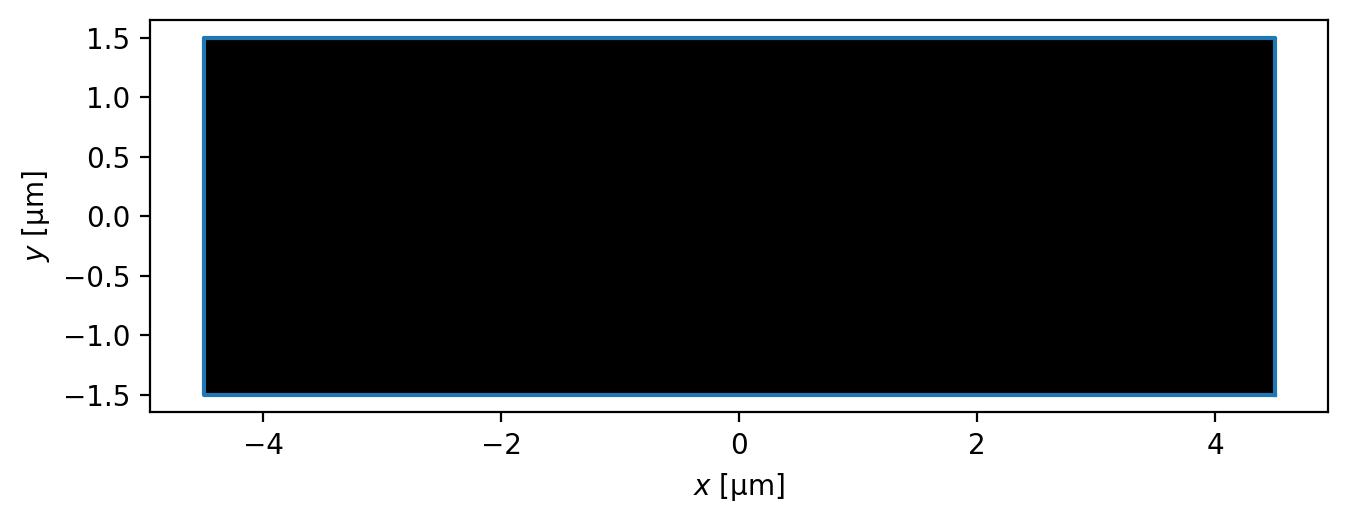

In [7]:
device.make_mesh(max_edge_length=xi / 4, smooth=100)
fig, ax = device.plot(mesh=True, legend=False)
device.mesh_stats()

### Check Unit
This scipts is based on unitless gTDGL funtion. So this cell is for cheking unit based on the parameters.


In [8]:
# PrintSet = True
PrintSet = False

## SC parameters
length_units = str(length_units)

if PrintSet: print('Length scale of sample')
mu_0 = cons.mu_0 * ureg('newton/A**2')
xi_coherent = xi * ureg(length_units)
if PrintSet: print('- Coherent length: {!s}'.format(xi_coherent))
lambdaL = london_lambda * ureg(length_units)
if PrintSet: print('- London penetration depth: {!s}'.format(lambdaL))
d_thickness = thickness * ureg(length_units)
lambdaL_eff = lambdaL**2/d_thickness
if PrintSet: print('- Effective London penetration depth (l^2/d): {!s}'.format(lambdaL_eff))
if PrintSet: print('- Thickness: {!s}'.format(d_thickness))
L_height = height * ureg(length_units)
L_width = width * ureg(length_units)
if PrintSet: print('- Height: {!s}'.format(L_height))
if PrintSet: print('- Width: {!s}'.format(L_width))
screen_length = lambdaL**2/d_thickness
if PrintSet: print('- Screen length: {!s}'.format(screen_length))

if PrintSet: print('Condictivitye of sample')
resistivity = 150e-6 * ureg('ohm * cm')
condictivity = 1/resistivity
if PrintSet: print('- Given resistivity: {!s}'.format(resistivity))
if PrintSet: print('- Given condictivity: {!s}'.format(condictivity))

if PrintSet: print('Gap of sample')
E_eph = rate_eph * ureg('meV')
E_gap_0 = gap_0 * ureg('meV')
F_gap_0 = gap_0*0.242 * ureg('THz')
if PrintSet: print('- Given inelastic coupling rate: {!s}'.format(E_eph))
if PrintSet: print('- Given SC gap energy: {!s}'.format(E_gap_0))
if PrintSet: print('- Given SC gap energy: {!s}'.format(F_gap_0))
if PrintSet: print('- Strength of inelastic scattering: {!s}'.format(gamma))


## Unit of Time

if PrintSet: print('Time scale of sample')
# tau_0 = 2 * ureg('s')# mu_0 * condictivity * lambdaL**2
tau_0 = mu_0 * condictivity * lambdaL**2
tau_0 = tau_0.to('s')
if PrintSet: print('- SC dissipation time (tau_0): {!s}'.format(tau_0.to(time_units)))
speed_of_light = cons.speed_of_light * ureg('m/s')
revised_speed_of_light = (speed_of_light*tau_0.to(time_units).magnitude)
if PrintSet: print('- Speed of light (unit of tau_0):  {!s}'.format(revised_speed_of_light.to('um/ps')))


## Angular frequency of 1 THz (ω =2πf)

if PrintSet: print('Given frequency of light')
w_Freq = (1/tau_0)
f_input = 1 * w_Freq
w_input = 2*np.pi * f_input
if PrintSet: print('- SC dissipation rate: {!s}'.format(w_Freq.to(angular_freq_units)))
if PrintSet: print('- Expected frequency of light: {!s}'.format(f_input.to(angular_freq_units)))
if PrintSet: print('- Expected angular frequency of light: {!s}'.format(w_input.to(angular_freq_units)))
w0 = ((speed_of_light/(f_input.to(angular_freq_units))).to('um'))
if PrintSet: print('- Wavelength estimation for w0: '+str(w0))
if PrintSet: print('- Useful ratio estimation w0/xi: '+str(w0/xi_coherent))
if PrintSet: print('- Useful ratio estimation xi/tau_GL: '+str(xi_coherent.to('um')/tau_0.to('ps')))
if PrintSet: print('- Useful ratio estimation w0/tau_LG: '+str(w0.to('um')/tau_0.to('ps')))


## Electrical field and Magnetic field Phi_0

if PrintSet: print('E and B of light')
c_rev = revised_speed_of_light.to(length_units+'/'+time_units).magnitude
B0_check = (1/(c_rev)) * ureg(field_units)#*tau_0.to(time_units).magnitude
A0_check = (1/2/np.pi) * ureg(f"{field_units} * {length_units}") # Suppose w_input = 2*pi
B0 = B0_check
E0 = B0 * speed_of_light
if PrintSet: print('- |E0| of light: {!s}'.format(E0.to(E_field_units)))
if PrintSet: print('- |B0| of light: {!s}'.format(B0.to(field_units)))
if PrintSet: print('- |B0| of inside the function: {!s}'.format(B0_check.to(field_units)))
if PrintSet: print('- |A0| of inside the function: {!s}'.format(A0_check.to(field_units+'*'+length_units)))
if PrintSet: print('- 2pi|A0|/|B0|=Wavelength defined inside the function: {!s}'.format((A0_check*2*np.pi/B0_check).to(length_units)))
    # superconducting flux quantum: Phi0 = h/2e
    # upper critical field: Bc2 = μ0Hc2 = Phi0/2πξ^2
if PrintSet: print('Critical E and B of SC')
Phi0 = cons.h/2/cons.e * ureg('J/A')
Hc1 = Phi0/4/np.pi/mu_0/lambdaL**2*np.log(lambdaL/xi_coherent) # [ref] Gennes.P.D., pp.66, Eq (3-56), but no mu_0
Hc2 = Phi0/2/np.pi/mu_0/xi_coherent**2 # [ref] Logan
Hc  = Hc1/(np.pi/np.sqrt(24)*xi_coherent/lambdaL*np.log(lambdaL/xi_coherent)) # [ref] Gennes.P.D., pp.66, Eq (3-56), but no mu_0
Bc1 = mu_0*Hc1
Bc2 = mu_0*Hc2
Bc  = mu_0*Hc
A0_critical = xi_coherent*Bc2
# Econd = (1/2)VN(0)Δ2
# Econd = # [ref] Gennes.P.D., pp.66, Eq (3-41)
# Econd = Hc1**2/8/np.pi # [ref] Gennes.P.D., pp.66, Eq (3-1) # Gauss unit
Econd = Bc**2/2/mu_0
hbar = cons.hbar * ureg('J*s')
vF = np.pi*xi_coherent*E_gap_0/hbar # [ref] Gennes.P.D., pp.66, Eq (3-40)
if PrintSet: print('- Phi0: {!s}'.format(Phi0))
if PrintSet: print('- Hc1 of SC: {!s}'.format(Hc1))
if PrintSet: print('- Hc2 of SC: {!s}'.format(Hc2))
if PrintSet: print('- Bc1 of SC: {!s}'.format(Bc1.to('T')))
if PrintSet: print('- Bc2 of SC: {!s}'.format(Bc2.to('T')))
if PrintSet: print('- Critical vector potential A0: {!s}'.format(A0_critical.to('T*um')))
J0 = 4*xi_coherent*Bc2/mu_0/lambdaL**2
if PrintSet: print('- Unit current density: {!s}'.format(J0.to('A/um^2')))
if PrintSet: print('- Condensation energy (Bc**2/2/mu0): {!s}'.format(Econd.to('eV/'+length_units+'**3')))

""" Done!"""


/usr/local/lib/python3.12/dist-packages/pint/facets/plain/quantity.py:1029: RuntimeWarning: invalid value encountered in scalar divide
  magnitude = magnitude_op(new_self._magnitude, other._magnitude)


' Done!'

### Setting of Laguerre-Gaussian Beam
Inputing the parameters for Laguerre-Gaussian Beam. <br>
!!! Impotent !!! this cell will clean up the files in filefolder @folder_name.

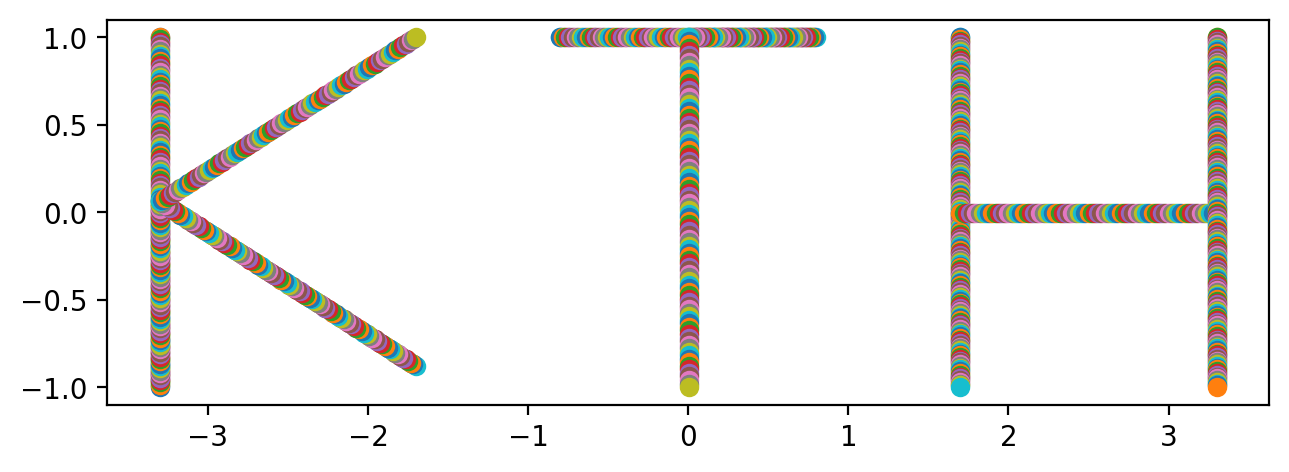

In [ ]:
plt.figure()
t2 = WriteSingleLetter(width=2.0,height=2.0,center=np.array([-2.5,0.0])) # width=1,height=1,center=[0,0]
t2.K()
for i in range(len(t2.trace[0,0:])):
    if t2.laser_intensity[i]>0.1: plt.plot(t2.trace[0,i],t2.trace[1,i],'o')
    else: plt.plot(t2.trace[0,i],t2.trace[1,i],'c.')
t2 = WriteSingleLetter(width=2.0,height=2.0,center=np.array([0.0,0.0])) # width=1,height=1,center=[0,0]
t2.T()
for i in range(len(t2.trace[0,:])):
    if t2.laser_intensity[i]>0.1: plt.plot(t2.trace[0,i],t2.trace[1,i],'o')
    else: plt.plot(t2.trace[0,i],t2.trace[1,i],'c.')
t2 = WriteSingleLetter(width=2.0,height=2.0,center=np.array([2.5,0.0])) # width=1,height=1,center=[0,0]
t2.H()
for i in range(len(t2.trace[0,:])):
    if t2.laser_intensity[i]>0.1: plt.plot(t2.trace[0,i],t2.trace[1,i],'o')
    else: plt.plot(t2.trace[0,i],t2.trace[1,i],'c.')

In [28]:
### Make filefolder for saving ###

Parameter_set = {}

quiver_scale = 2
xc_Gauss = 0
yc_Gauss = 0
gamma = 10
light_source_type = 'lg00_c_l'

### Parameter setting ###

case_name, E0i, w0, current_amp = 'UCONN', 75, 0.3, 0.0

Parameter_set[case_name] = {'E0i':E0i,'light_source_type':light_source_type,'current_amp':current_amp}
w_input = 2*np.pi / 4
solve_time = 80
screenSet = False
constant_Bz = 0
t_on, t_off, time_evolute = [0, solve_time, True]
quiver_mesh_n = 20
# quiver_scale = 5
width_quiver = 0.1
dpi = 100
SC_solution_all = {}

### Generate Letter

pt_1, pt_2, pt_3 = -3.3, 1.6, 1.2
U_trace = WriteSingleLetter(width=pt_3,height=2.0,center=np.array([pt_1,0.0])) # width=1,height=1,center=[0,0]
U_trace.U()
U_trace.TimeRescale(0,15) # Rescale of timeline of laser trace
C_trace = WriteSingleLetter(width=pt_3,height=2.0,center=np.array([pt_1+pt_2,0.0])) # width=1,height=1,center=[0,0]
C_trace.C()
C_trace.TimeRescale(15,30) # Rescale of timeline of laser trace
O_trace = WriteSingleLetter(width=pt_3,height=2.0,center=np.array([pt_1+pt_2*2,0.0])) # width=1,height=1,center=[0,0]
O_trace.O()
O_trace.TimeRescale(30,45) # Rescale of timeline of laser trace
N_trace = WriteSingleLetter(width=pt_3,height=2.0,center=np.array([pt_1+pt_2*3,0.0])) # width=1,height=1,center=[0,0]
N_trace.N()
N_trace.TimeRescale(45,60) # Rescale of timeline of laser trace
N2_trace = WriteSingleLetter(width=pt_3,height=2.0,center=np.array([pt_1+pt_2*4,0.0])) # width=1,height=1,center=[0,0]
N2_trace.N()
N2_trace.TimeRescale(60,75) # Rescale of timeline of laser trace

# Output to array
trace_pos, trace_time, laser_shutter = np.array([0.0,0.0]), np.array([0.0]), np.array([0.0])
letters = [U_trace, C_trace, O_trace, N_trace, N2_trace]
for nl in range(len(letters)):
  letter_load = letters[nl]
  for i in range(len(letter_load.timestep)):
    trace_pos = np.concatenate((trace_pos,letter_load.trace[:,i]))
    trace_time = np.concatenate((trace_time,[letter_load.timestep[i]]))
    laser_shutter = np.concatenate((laser_shutter,[letter_load.laser_intensity[i]]))
trace_pos = np.array(trace_pos)
trace_pos = np.reshape(trace_pos,(len(trace_time),2)).T
""" Done ! """


' Done ! '

## Demonstrate device and confirm the writing

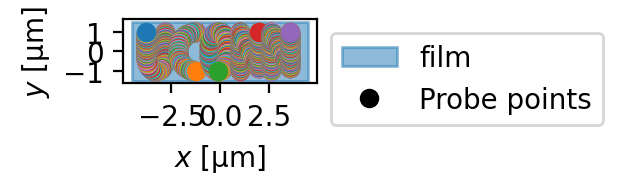

In [29]:

### Plot device

fluxoid_curves = [
    box(2, center=(-2.5, 0)),
    box(2, center=(2.5, 0)),
]


### Demonstrate Letter

fig, ax = device.draw()
# plt.figure()
for i in range(len(trace_pos[0,:])):
    if laser_shutter[i]>0.1: plt.plot(trace_pos[0,i],trace_pos[1,i],'o')
    else: plt.plot(trace_pos[0,i],trace_pos[1,i],'c.')

### Rescale of timeline of laser trace
# plt.figure()
# plt.plot(laser_trace.timestep)

### Get the position at time_input (demo)
# time_input = 4
# print(FindPos(time_input,laser_trace.timestep,laser_trace.trace)) # FindPos(time,time_array,trace_array)


### Part 2: Solve of device
Calculation and demonstration of gTDGL simtlation.

In [ ]:
# import cupy as cp
Execute_GPU = False

### Loop of calculation

# import tempfile
# tempdir = tempfile.TemporaryDirectory()
# tempdir = os.path.join(os.ugetcwd(),folder_name)
length_units = str(length_units)
print('Save')

# Set for snapshot
tn_set = [0,5,10,15,20,30,40,50,60]


for num_set in Parameter_set:

    E0i = np.copy(Parameter_set[num_set]['E0i'])
    light_source_type = str(Parameter_set[num_set]['light_source_type'])
    subtitle = '20250919_write_project_'+num_set+'_'
    newpath = r'/content/drive/MyDrive/Colab Notebooks/TempData/20250919_write_project_'+num_set

    terminal_currents=dict(source=current_amp, drain=-current_amp)

    ## Select the parameters for the states of light sourceu
    ## options: 'lg00_l_x','lg00_l_y','lg00_c_l','lg00_c_r','lg01_l_x','lg01_l_y','lg01_c_c','lg01_c_r','lg01_c_a'
    p, l, s, phi0_t, phi0_xy, polarization_modulation, output_file_head = light_state_contral(light_source_type)

    if not os.path.exists(newpath): os.makedirs(newpath)
    folder_name = newpath
    tempdir = newpath
    vedio_file_head = '_time'+str(solve_time)+'_SC_solution'+num_set
    options = tdgl.SolverOptions(
        solve_time=solve_time,
        field_units=field_units,
        current_units=current_units,
        include_screening=screenSet,
        screening_tolerance=5e-2,
        max_iterations_per_step=200000,
        screening_step_size=0.01,
        screening_step_drag=0.5,
        save_every=50,
        dt_max=5e-2,
        output_file=os.path.join(tempdir, output_file_head+vedio_file_head+".h5"),
        gpu=Execute_GPU,
    )

    ### Save and print

    def E_input_frame(Xv,Yv,ti,*,take_real: bool=True):
        Zv = np.zeros_like(Xv)
        Ex, Ey, Ez =  (E_LG_t(Xv, Yv, Zv, t=ti, w=w_input, w0=w0, E0=E0i, xc_Gauss=xc_Gauss, yc_Gauss=yc_Gauss,
                                phi0_t=phi0_t, phi0_xy=phi0_xy, p=p, l=l, s=s,
                                tau=tau_0.to(time_units).magnitude, polarization_modulation=polarization_modulation,
                                t_on=t_on, t_off=t_off, Bz=constant_Bz, time_evolute=time_evolute,
                                angular_freq_units=angular_freq_units, length_units=length_units, E_field_units=E_field_units, time_units=time_units,
                                trace_pos=trace_pos, trace_time=trace_time, laser_shutter=laser_shutter,))
        if take_real: return np.real(Ex)/E0i, np.real(Ey)/E0i
        else:         return Ex/E0i, Ey/E0i

    delete_files_in_directory(folder_name)
    fig_title0 = folder_name+'/'+subtitle+output_file_head
    X, Y, Xv, Yv, Zv = v_grid_generation(-width/2,width/2,-height/2,height/2,quiver_mesh_n)
    Bz_max = find_max_Bz(Xv,Yv,1,0,revised_speed_of_light.to('um/ps').magnitude,w_input)
    tau, c = Unit_check_save(E0i,w0,w_input,light_source_type,length_units,E_field_units,angular_freq_units,subtitle,solve_time,screenSet,folder_name,Bz_max)
    fig, ax = device.plot(mesh=True, legend=False)
    device.mesh_stats()
    plt.savefig(fig_title0+'_device.png')
    fig, ax = device.draw()
    for i in range(len(trace_pos[0,:])):
        if laser_shutter[i]>0.1: plt.plot(trace_pos[0,i],trace_pos[1,i],'o')
        else: plt.plot(trace_pos[0,i],trace_pos[1,i],'c.')
    plt.savefig(fig_title0+'_config.png')

    quiver_test = True
    if quiver_test:
            title_set = 'quiver test'
            E_x, E_y, E_z = (E_LG_t(Xv, Yv, Zv, t=4, w=w_input, w0=w0, E0=E0i, xc_Gauss=xc_Gauss, yc_Gauss=yc_Gauss,
                                    phi0_t=0*np.pi/2, phi0_xy=phi0_xy, p=p, l=l, s=s,
                                    t_on=t_on, t_off=t_off, Bz=constant_Bz, time_evolute=time_evolute,
                                    tau=tau_0.to(time_units).magnitude, polarization_modulation=polarization_modulation,
                                    angular_freq_units=angular_freq_units, length_units=length_units, E_field_units=E_field_units, time_units=time_units,
                                    trace_pos=trace_pos, trace_time=trace_time, laser_shutter=laser_shutter,))
            B_x, B_y, B_z = E2Bv(Xv,Yv,E_x,E_y,constant_Bz,c,w_input)
            Bz_max = B_z
            plot_EM(X,Y,np.real(E_x),np.real(E_y),np.real(B_z),E0i=E0i,title=title_set,figsize=(9,3),scale=quiver_scale,dpi=dpi,width_quiver=width_quiver)
            print('Bz/Bc2 tatio:')
            # print(Bz_max/Bc2.to(field_units).magnitude)

    ### Solve device

    print('num_set: '+num_set)
    # if Execute_GPU:
    #       applied_vector_potential = A_LG_cupy(w=w_input, w0=w0, E0=E0i, phi0_t=phi0_t, phi0_xy=phi0_xy, p=p, l=l, s=s, c=c, tau=tau_0.to(time_units).magnitude, polarization_modulation=polarization_modulation, xc_Gauss=xc_Gauss, yc_Gauss=yc_Gauss,
    #                              t_on=t_on, t_off=t_off, Bz=constant_Bz, time_evolute=time_evolute, angular_freq_units=angular_freq_units, length_units=length_units, E_field_units=E_field_units, time_units=time_units,)
    # else:
    applied_vector_potential = A_LG(w=w_input, w0=w0, E0=E0i, phi0_t=phi0_t, phi0_xy=phi0_xy, p=p, l=l, s=s, c=c, tau=tau_0.to(time_units).magnitude, polarization_modulation=polarization_modulation, xc_Gauss=xc_Gauss, yc_Gauss=yc_Gauss,
                                t_on=t_on, t_off=t_off, Bz=constant_Bz, time_evolute=time_evolute, angular_freq_units=angular_freq_units, length_units=length_units, E_field_units=E_field_units, time_units=time_units,
                                trace_pos=trace_pos, trace_time=trace_time, laser_shutter=laser_shutter,)
    SC_solution = tdgl.solve(device, options, applied_vector_potential=applied_vector_potential,disorder_epsilon=disorder_epsilon,terminal_currents=terminal_currents,)

     ### Plot the descrite time step of simulation

    plt.rcParams["figure.figsize"] = (3, 3)
    plt.figure()
    plt.plot(SC_solution.times,'.')
    fig_title = folder_name+'/'+subtitle+output_file_head+'_'+str(num_set)
    plt.savefig(fig_title+'_t.png')

    ### Demonstrate the electrical field, order parameter, vorticity, scalar potential from tn_set

    print(tn_set * tau_0.to('femtosecond'))

    for nt in range(len(tn_set)):
        ti = tn_set[nt]
        # title_set = label_set[nt]+' period (time:'+str(int(ti*100)/100)+' $\\tau_0$)'
        title_set = 'time:'+str(int(ti*100)/100)+' $\\tau_0$'
        E_x, E_y, E_z = (E_LG_t(Xv, Yv, Zv, t=ti, w=w_input, w0=w0, E0=E0i, xc_Gauss=xc_Gauss, yc_Gauss=yc_Gauss,
                                 phi0_t=phi0_t, phi0_xy=phi0_xy, p=p, l=l, s=s,
                                 t_on=t_on, t_off=t_off, Bz=constant_Bz, time_evolute=time_evolute,
                                 tau=tau_0.to(time_units).magnitude, polarization_modulation=polarization_modulation,
                                 angular_freq_units=angular_freq_units, length_units=length_units, E_field_units=E_field_units, time_units=time_units,
                                 trace_pos=trace_pos, trace_time=trace_time, laser_shutter=laser_shutter,))
        B_x, B_y, B_z = E2Bv(Xv,Yv,E_x,E_y,constant_Bz,c,w_input)
        plot_EM(X,Y,np.real(E_x),np.real(E_y),np.real(B_z),E0i=E0i,title=title_set,figsize=(9,3),scale=quiver_scale,dpi=dpi,width_quiver=width_quiver)
        plt.savefig(fig_title+'_'+str(nt)+'_E.png')

        SC_solution.solve_step = SC_solution.closest_solve_step(ti)
        # print('Step number: '+str(SC_solution.solve_step))
        fig, axes = SC_solution.plot_order_parameter(figsize=(10, 3),dpi=dpi)
        plt.savefig(fig_title+'_'+str(nt)+'_1.png')

        fig, axes = plt.subplots(1, 2, figsize=(9, 3),dpi=dpi)
        _ = SC_solution.plot_vorticity(ax=axes[0]) #, streamplot=False
        _ = SC_solution.plot_currents(ax=axes[1]) #, streamplot=False
        plt.savefig(fig_title+'_'+str(nt)+'_2.png')
    SC_solution_all.update({num_set:SC_solution})

    # plt.rcParams['figure.figsize'] = [6, 10]
    # fig, axes = SC_solution.dynamics.plot()
    # # for ax in axes:
    # #     ax.axvline(t0, color="k", alpha=0.5)
    # plt.savefig(fig_title0+'_'+str(nt)+'_probe.png')

    ### Make video
    ### Excute "conda install -c conda-forge ffmpeg" at Anaconda

    if MAKE_ANIMATIONS:
        output_video = make_video_from_solution(
            SC_solution,
            quantities=["order_parameter", "phase","vorticity"],
            figsize=(18, 5),
            fps=20,
            dpi=100,
            quiver_scale=quiver_scale,
            quiver_mesh_n=quiver_mesh_n,
            output_file=fig_title+"_video.mp4",
        )

        # display(output_video)

    # print("Save Zip file as:")
    # file_name = subtitle+output_file_head+'_E'+str(E0i)
    # shutil.make_archive(file_name, format='zip', root_dir='temp')
    # delete_files_in_directory(folder_name)
    # shutil.move('/content/'+file_name+'.zip', '/content/drive/MyDrive/Colab Notebooks/data_collect/')



Save
All files deleted successfully.
[Warning] !!! ---Beam size is smaller than wavelength.--- !!!
File name /content/drive/MyDrive/Colab Notebooks/TempData/20250919_write_project_UCONN/20250919_write_project_UCONN_LG00_circular_l_rec.txt
Time now (at Stockholm):2025-10-10 17:45:36.222343+02:00
:: Parameter record ::
[1] Length scale of sample
Coherent length (xi): 0.1 micrometer
London penetration depth (london_lambda): 0.1 micrometer
Thickness (thickness): 0.002 micrometer
Screen length (lambdaL**2/thickness): 5.000000000000001 micrometer
Ratio of length kapa (lambdaL/xi): 1.0 dimensionless
[2] Condictivity and  of sample
Resistivity (resistivity): 0.00015 centimeter * ohm
Condictivity (1/resistivity): 6666.666666666667 / centimeter / ohm
[3] Time scale of sample
Characteristic timescale (tau_0): 0.00837758040846667 picosecond
Characteristic rate (1/tau_0): 119.36620733468172 terahertz
Speed of light (unit of tau_0): 2511535.422746867 meter / second
c input into A_LG (c): 2.511535422

/tmp/ipython-input-1794634288.py:636: UserWarning: linewidths is ignored by contourf
  contour_Bz = ax2.contourf(Xv, Yv, B_z, levels=50, linewidths=0.0, cmap="PRGn",vmin=Bzmin,vmax=Bzmax)


Bz/Bc2 tatio:
num_set: UCONN


Simulating:   8%|▊         | 6/80 [32:04<5:08:09, 251.39s/tau ]

In [ ]:
SC_solution.vorticity

Bc2.to(field_units).magnitude
int(abs(B_z.max()) * ureg(field_units) /Bc2.to(field_units))

len(SC_solution_all[num_set].times)
i+1
# SC_solution_all[num_set].times[i]
# recall_solution1 = SC_solution_all['1']#.tdgl_data
# recall_solution1.solve_step
# recall_solution2 = SC_solution_all['2']#.tdgl_data

# import h5py
# h5py.File(path2,'r+')
# SC_solution2.solve_step
# path2 = os.path.join(tempdir, output_file_head+vedio_file_head+".h5")
# SC_solution2.load_tdgl_data(solve_step=1,h5file:h5py.File(path2,'r+'))

SC_solution1.times

path2 = os.path.join(tempdir, output_file_head+vedio_file_head+".h5")
h5py.File(path2,'r+')

NameError: name 'i' is not defined

In [ ]:

psi_timetrace1 = np.zeros_like(SC_solution1.times)
# psi_timetrace2 = np.zeros_like(SC_solution2.times)

plt.figure()

for i in tqdm(range(len(SC_solution1.times))):
    SC_solution1.solve_step = i
    psi_timetrace1[i] = sum(np.abs(SC_solution1.tdgl_data.psi))
plt.plot(SC_solution1.times, psi_timetrace1)

# for i in tqdm(range(len(SC_solution2.times))):
#     SC_solution2.solve_step = i
#     psi_timetrace2[i] = sum(np.abs(SC_solution2.tdgl_data.psi))
# plt.plot(SC_solution2.times, psi_timetrace2)

# num_set = '2'
# for i in tqdm(range(len(SC_solution_all[num_set].times))):
#     SC_solution_all[num_set].solve_step = i
#     psi_gamma0_timetrace[i] = sum(np.abs(SC_solution_all[num_set].tdgl_data.psi))
# plt.plot(SC_solution_all[num_set].times, psi_gamma0_timetrace)

In [ ]:
from tdgl.finite_volume.operators import build_gradient

# ti = 1
# https://matplotlib.org/stable/users/explain/colors/colormaps.html
mag_cmap = "gnuplot"#"viridis"
phase_cmap = "BrBG"#"twilight_shifted"
vorticity_cmap = "bwr"
shading = "gouraud"
psi_label = "$|\\psi|$"
phase_label = "$\\theta / \\pi$"
vorticity_label = "$\\omega_{v,s}$"
dpi = 600
length_units = device.ureg(device.length_units).units

# f, axes  = plt.subplots(nrows=len(Parameter_set), ncols=2, sharey=True, sharex=True, figsize=(3,4.4), constrained_layout=True, dpi=dpi)

for num_set in Parameter_set:

    f, ax = plt.subplots(nrows=1, ncols=1, figsize=(2,2.5), constrained_layout=True, dpi=dpi, sharey=True)

    phi0_t = np.copy(Parameter_set[num_set]['phi0_t'])
    E_x, E_y, E_z = (E_pulse_t(Xv, Yv, Zv, t=ti, w=w_input, w0=w0, E0=E0i, xc_Gauss=xc_Gauss, yc_Gauss=yc_Gauss,
                                 phi0_t=phi0_t, phi0_xy=phi0_xy, p=p, l=l, s=s, t0_gtt=t0_gtt, tau_gtt=tau_gtt,
                                 t_on=t_on, t_off=t_off, Bz=constant_Bz, time_evolute=time_evolute,
                                 tau=tau_0.to(time_units).magnitude, polarization_modulation=polarization_modulation,
                                 angular_freq_units=angular_freq_units, length_units=length_units, E_field_units=E_field_units, time_units=time_units,))
    B_x, B_y, B_z = E2Bv(Xv,Yv,E_x,E_y,constant_Bz,c,w_input)
    dx, dy = [abs(X[2]-X[1]),abs(Y[2]-Y[1])]
    ds = dx*dy
    PhiB = B_z * ds
    PhiB = PhiB / Bc2.to(field_units).magnitude / ds # normalization
    vrange = int(abs(B_z.max()) * ureg(field_units) /Bc2.to(field_units))
    contour_PhiB = ax.contourf(Xv/xi, Yv/xi, PhiB, levels=100, linewidths=0.0, cmap="PRGn",vmin=-vrange,vmax=vrange)
    cbar = f.colorbar(contour_PhiB,ax=ax,location='top', ticks=[-vrange, 0, vrange])
    cbar.set_label('$\\Phi_{B}/\\Phi_{Bc2}$')
    # ax.quiver(X/xi,Y/xi,E_x/E0i,E_y/E0i,scale=quiver_scale, scale_units='x',width=width_quiver*abs(X[2]-X[1]))
    circle = plt.Circle((0, 0), w0/xi, color='c',fill=False,linestyle='--')
    ax.add_patch(circle)
    ax.set_xlim([min(X/xi),max(X/xi)])
    ax.set_ylim([min(Y/xi),max(Y/xi)])
    ax.set_xlabel('$x/\\xi$ [$$]')#(f"$x$ [${length_units:~L}$]")
    ax.set_ylabel('$y/\\xi$ [$\\xi$]')#(f"$y$ [${length_units:~L}$]")
    ax.set_aspect("equal")

    fig_title = folder_name+'/'+subtitle+output_file_head+'_result'
    plt.savefig(fig_title+'_distri_'+num_set+'_PhiB.png')
    print('Save figure as ... '+fig_title+'_distri_'+num_set+'_PhiB.png')

    f, axes = plt.subplots(nrows=1, ncols=3, figsize=(4.8,2.5), constrained_layout=True, dpi=dpi, sharey=True)

    psi = np.copy(SC_solution_all[num_set].tdgl_data.psi)
    mag = np.abs(psi)
    phase = np.angle(psi) / np.pi
    points = device.points
    triangles = device.triangles

    ax = axes[0]
    im = ax.tripcolor(
        points[:, 0]/xi,
        points[:, 1]/xi,
        mag,
        triangles=triangles,
        vmin=0,
        vmax=1,
        cmap=mag_cmap,
        shading=shading,
    )
    circle = plt.Circle((0, 0), w0/xi, color='c',fill=False,linestyle='--')
    ax.add_patch(circle)
    ax.set_xlim([min(points[:, 0]/xi),max(points[:, 0]/xi)])
    ax.set_ylim([min(points[:, 0]/xi),max(points[:, 0]/xi)])
    cbar = f.colorbar(im, ax=ax,location='top')
    cbar.set_label(psi_label)
    ax.set_xlabel('$x$ [$\\xi$]')#(f"$x$ [${length_units:~L}$]")
    ax.set_ylabel('$y$ [$\\xi$]')#(f"$y$ [${length_units:~L}$]")
    ax.set_aspect('equal')

    ax = axes[1]
    im = ax.tripcolor(
        points[:, 0]/xi,
        points[:, 1]/xi,
        phase,
        triangles=triangles,
        vmin=-1,
        vmax=1,
        cmap=phase_cmap,
        shading=shading,
    )
    ax.set_xlim([min(points[:, 0]/xi),max(points[:, 0]/xi)])
    ax.set_ylim([min(points[:, 0]/xi),max(points[:, 0]/xi)])
    cbar = f.colorbar(im, ax=ax,location='top')
    cbar.set_label(phase_label)
    ax.set_xlabel('$x$ [$\\xi$]')#(f"$x$ [${length_units:~L}$]")
    ax.set_aspect('equal')

    ### Calculate vorticity
    mu = np.copy(SC_solution_all[num_set].tdgl_data.mu)
    epsilon = np.copy(SC_solution_all[num_set].tdgl_data.epsilon)
    a_applied = np.copy(SC_solution_all[num_set].tdgl_data.applied_vector_potential)
    a_induced = np.copy(SC_solution_all[num_set].tdgl_data.induced_vector_potential)
    supercurrent = np.copy(SC_solution_all[num_set].tdgl_data.supercurrent)
    normal_current = np.copy(SC_solution_all[num_set].tdgl_data.normal_current)*0
    nsites = len(device.mesh.sites)
    j_sc_site = device.mesh.get_quantity_on_site(supercurrent)
    j_nm_site = device.mesh.get_quantity_on_site(normal_current)
    j_site = j_sc_site + j_nm_site
    gradient = build_gradient(device.mesh)
    normalized_directions = device.mesh.edge_mesh.normalized_directions
    grad_jx = gradient @ j_site[:, 0]
    grad_jy = gradient @ j_site[:, 1]
    djy_dx = grad_jy * normalized_directions[:, 0]
    djx_dy = grad_jx * normalized_directions[:, 1]
    vorticity_on_edges = djy_dx - djx_dy
    vorticity = device.mesh.get_quantity_on_site(vorticity_on_edges, vector=False)
    vor_max = max(abs(vorticity))

    ax = axes[2]
    im = ax.tripcolor(
        points[:, 0]/xi,
        points[:, 1]/xi,
        vorticity/vor_max,
        triangles=triangles,
        vmin=-1,
        vmax=1,
        cmap=vorticity_cmap,
        shading=shading,
    )
    ax.set_xlim([min(points[:, 0]/xi),max(points[:, 0]/xi)])
    ax.set_ylim([min(points[:, 0]/xi),max(points[:, 0]/xi)])
    cbar = f.colorbar(im, ax=ax,location='top')
    cbar.set_label(vorticity_label)
    ax.set_xlabel('$x$ [$\\xi$]')#(f"$x$ [${length_units:~L}$]")
    ax.set_aspect('equal')

    fig_title = folder_name+'/'+subtitle+output_file_head+'_result'
    plt.savefig(fig_title+'_distri_'+num_set+'_psi.png')
    print('Save figure as ... '+fig_title+'_distri_'+num_set+'_psi.png')

# if not os.path.exists(newpath): os.makedirs(newpath)
#     folder_name = newpath
# fig_title = folder_name+'/'+subtitle+output_file_head+'_result'
# plt.savefig(fig_title+'_distri.png')
# print('Save figure as ... '+fig_title+'_distri.png')


# Note

In [ ]:
SC_solution_all[num_set].tdgl_data

KeyError: 2

In [ ]:
tdgl.version_table()
# # temperature
# # (1*ureg(length_units)).to(length_units).magnitude
# # ureg(length_units)
# ureg('micrometer')
# ureg(str(length_units))
# SC_solution_all['4'].solve_step
ti
SC_solution_all['4'].closest_solve_step(ti)

112

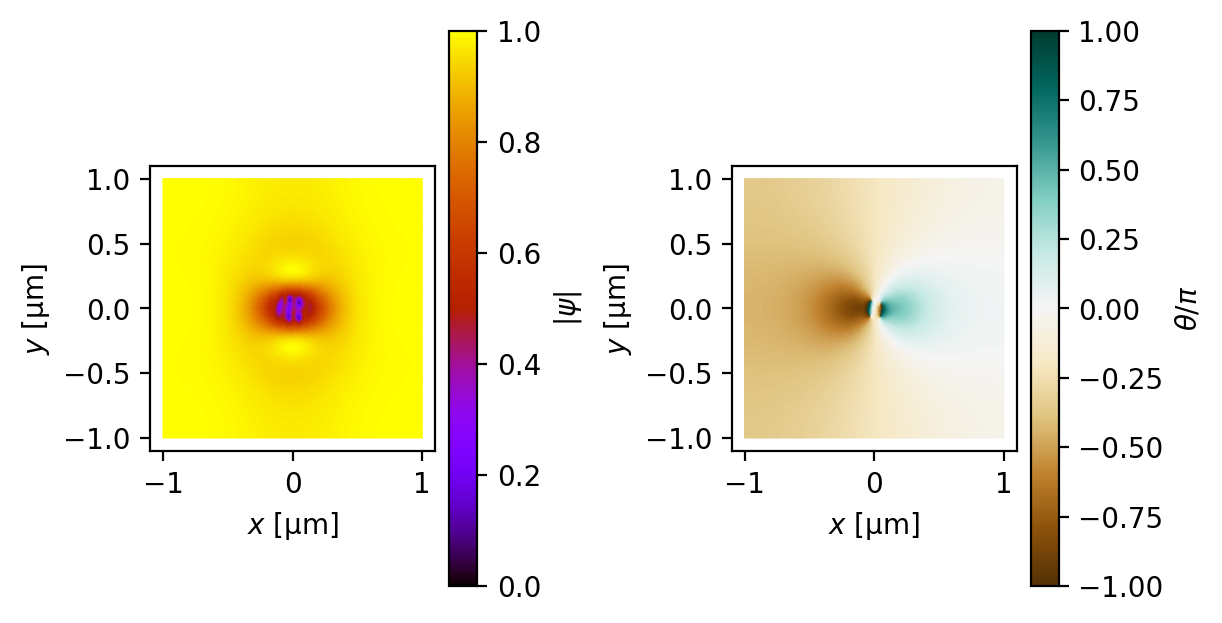

In [ ]:
# ti = 1
mag_cmap = "gnuplot"#"viridis"
phase_cmap = "BrBG"#"twilight_shifted"
shading = "gouraud"
psi_label = "$|\\psi|$"
phase_label = "$\\theta / \\pi$"

if True:
    # SC_solution_all['4'].solve_step = SC_solution_all['4'].closest_solve_step(ti)
    psi = SC_solution_all['4'].tdgl_data.psi
    mag = np.abs(psi)
    phase = np.angle(psi) / np.pi
    points = device.points
    triangles = device.triangles
    fig, axes = plt.subplots(1, 2, figsize=(6,3), constrained_layout=True)
    im = axes[0].tripcolor(
        points[:, 0],
        points[:, 1],
        mag,
        triangles=triangles,
        vmin=0,
        vmax=1,
        cmap=mag_cmap,
        shading=shading,
    )
    cbar = fig.colorbar(im, ax=axes[0])
    cbar.set_label(psi_label)
    im = axes[1].tripcolor(
        points[:, 0],
        points[:, 1],
        phase,
        triangles=triangles,
        vmin=-1,
        vmax=1,
        cmap=phase_cmap,
        shading=shading,
    )
    cbar = fig.colorbar(im, ax=axes[1])
    cbar.set_label(phase_label)
    length_units = device.ureg(device.length_units).units
    for ax in axes:
        ax.set_aspect("equal")
        ax.set_xlabel(f"$x$ [${length_units:~L}$]")
        ax.set_ylabel(f"$y$ [${length_units:~L}$]")

In [ ]:
int(num_set)
len(Parameter_set)

2

In [ ]:
# First create some toy data:
x = np.linspace(0, 2*np.pi, 400)
y = np.sin(x**2)

# Creates just a figure and only one subplot
fig, ax = plt.subplots()
ax.plot(x, y)
ax.set_title('Simple plot')

# Creates two subplots and unpacks the output array immediately
f, ax  = plt.subplots(1, len(Parameter_set), sharey=True)
ax1.plot(x, y)
ax1.set_title('Sharing Y axis')
ax2.scatter(x, y)

# Creates four polar axes, and accesses them through the returned array
fig, axes = plt.subplots(2, 2, subplot_kw=dict(polar=True))
axes[0, 0].plot(x, y)
axes[1, 1].scatter(x, y)

# Share a X axis with each column of subplots
plt.subplots(2, 2, sharex='col')

# Share a Y axis with each row of subplots
plt.subplots(2, 2, sharey='row')

# Share both X and Y axes with all subplots
plt.subplots(2, 2, sharex='all', sharey='all')

# Note that this is the same as
plt.subplots(2, 2, sharex=True, sharey=True)

# Creates figure number 10 with a single subplot
# and clears it if it already exists.
fig, ax=plt.subplots(num=10, clear=True)

In [ ]:
# w=w_input, w0=w0, E0=E0i,
#                                  phi0_t=phi0_t, phi0_xy=phi0_xy, p=p, l=l, s=s, c=c,
#                                  tau=tau_0.to(time_units).magnitude, polarization_modulation=polarization_modulation,
#                                  t_on=t_on, t_off=t_off, Bz=constant_Bz, time_evolute=time_evolute,
#                                  angular_freq_units=angular_freq_units, length_units=length_units, E_field_units=E_field_units, time_units=time_units
# zR = n*k*w0**2/2

w_input
# s
# tau_0.to(time_units).magnitude
# w0
# n

3.141592653589793

In [ ]:
import cupy as cp

### Loop of calculation

# import tempfile
# tempdir = tempfile.TemporaryDirectory()
# tempdir = os.path.join(os.getcwd(),folder_name)
length_units = str(length_units)
print('Save')

# Set for snapshot
# tn_set = [0,0.5,1, 2, 3, 4, 6,7,8,9,10]
tn_set = [0,0.5,1,2,3,4]


for num_set in Parameter_set:

    gamma = np.copy(Parameter_set[num_set]['gamma'])
    E0i = E0i_set[0]
    subtitle = '20240522_M1fig2b_'+num_set+'_'
    newpath = r'/content/drive/MyDrive/Colab Notebooks/TempData/20240522_M1fig2b'+num_set

    ## Select the parameters for the states of light sourceu
    ## options: 'lg00_l_x','lg00_l_y','lg00_c_l','lg00_c_r','lg01_l_x','lg01_l_y','lg01_c_c','lg01_c_r','lg01_c_a'
    p, l, s, phi0_t, phi0_xy, polarization_modulation, output_file_head = light_state_contral(light_source_type)

    layer = tdgl.Layer(coherence_length=xi, london_lambda=london_lambda, thickness=thickness, gamma=gamma, u=u, conductivity=condictivity.magnitude)
    film = tdgl.Polygon("film", points=tdgl.geometry.box(width, height, points=301))
    device = tdgl.Device(
        "bar",
        layer=layer,
        film=film,
        length_units=length_units,
    )

    device.make_mesh(max_edge_length=xi / 4, smooth=100)
    fig, ax = device.plot(mesh=True, legend=False)
    device.mesh_stats()

    if not os.path.exists(newpath): os.makedirs(newpath)
    folder_name = newpath
    tempdir = newpath
    vedio_file_head = '_time'+str(solve_time)+'_SC_solution'
    options = tdgl.SolverOptions(
        solve_time=solve_time,
        field_units=field_units,
        current_units=current_units,
        include_screening=screenSet,
        screening_tolerance=5e-2,
        max_iterations_per_step=200000,
        screening_step_size=0.01,
        screening_step_drag=0.5,
        save_every=10,
        dt_max=5e-3,
        output_file=os.path.join(tempdir, output_file_head+vedio_file_head+".h5"),
        gpu=Execute_GPU,
    )

    ### Save and print

    def E_input_frame(Xv,Yv,ti,*,take_real: bool=True):
        Zv = np.zeros_like(Xv)
        Ex, Ey, Ez =  (E_pulse_t(Xv, Yv, Zv, t=ti, w=w_input, w0=w0, E0=E0i, xc_Gauss=xc_Gauss, yc_Gauss=yc_Gauss,
                                phi0_t=phi0_t, phi0_xy=phi0_xy, p=p, l=l, s=s, t0_gtt=t0_gtt, tau_gtt=tau_gtt,
                                tau=tau_0.to(time_units).magnitude, polarization_modulation=polarization_modulation,
                                t_on=t_on, t_off=t_off, Bz=constant_Bz, time_evolute=time_evolute,
                                angular_freq_units=angular_freq_units, length_units=length_units, E_field_units=E_field_units, time_units=time_units,))
        if take_real: return np.real(Ex)/E0i, np.real(Ey)/E0i
        else:         return Ex/E0i, Ey/E0i

    delete_files_in_directory(folder_name)
    fig_title0 = folder_name+'/'+subtitle+output_file_head
    X, Y, Xv, Yv, Zv = v_grid_generation(-width/2,width/2,-height/2,height/2,quiver_mesh_n)
    Bz_max = find_max_Bz(Xv,Yv,1,0,revised_speed_of_light.to('um/ps').magnitude,w_input)
    tau, c = Unit_check_save(E0i_set,w0,w_input,light_source_type,length_units,E_field_units,angular_freq_units,subtitle,solve_time,screenSet,folder_name,Bz_max)
    fig, ax = device.plot(mesh=True, legend=False)
    device.mesh_stats()
    plt.savefig(fig_title0+'_device.png')

    quiver_test = True
    if quiver_test:
            title_set = 'quiver test'
            E_x, E_y, E_z = (E_pulse_t(Xv, Yv, Zv, t=0, w=w_input, w0=w0, E0=E0i_set[0], xc_Gauss=xc_Gauss, yc_Gauss=yc_Gauss,
                                    phi0_t=0*np.pi/2, phi0_xy=phi0_xy, p=p, l=l, s=s, t0_gtt=t0_gtt, tau_gtt=tau_gtt,
                                    t_on=t_on, t_off=t_off, Bz=constant_Bz, time_evolute=time_evolute,
                                    tau=tau_0.to(time_units).magnitude, polarization_modulation=polarization_modulation,
                                    angular_freq_units=angular_freq_units, length_units=length_units, E_field_units=E_field_units, time_units=time_units,))
            B_x, B_y, B_z = E2Bv(Xv,Yv,E_x,E_y,constant_Bz,c,w_input)
            plot_EM(X,Y,np.real(E_x),np.real(E_y),np.real(B_z),E0i=E0i_set[0],title=title_set,figsize=(9,3),scale=quiver_scale,dpi=dpi,width_quiver=width_quiver)

    ### Solve device

    print('num_set: '+num_set)
    # if Execute_GPU:
    #       applied_vector_potential = A_pulse_cupy(w=w_input, w0=w0, E0=E0i, phi0_t=phi0_t, phi0_xy=phi0_xy, p=p, l=l, s=s, c=c, tau=tau_0.to(time_units).magnitude, polarization_modulation=polarization_modulation, xc_Gauss=xc_Gauss, yc_Gauss=yc_Gauss,
    #                              t_on=t_on, t_off=t_off, Bz=constant_Bz, time_evolute=time_evolute, angular_freq_units=angular_freq_units, length_units=length_units, E_field_units=E_field_units, time_units=time_units,)
    # else:
    applied_vector_potential = A_pulse(w=w_input, w0=w0, E0=E0i, phi0_t=phi0_t, phi0_xy=phi0_xy, p=p, l=l, s=s, c=c, tau=tau_0.to(time_units).magnitude, polarization_modulation=polarization_modulation, xc_Gauss=xc_Gauss, yc_Gauss=yc_Gauss,
                                  t0_gtt=t0_gtt, tau_gtt=tau_gtt,t_on=t_on, t_off=t_off, Bz=constant_Bz, time_evolute=time_evolute, angular_freq_units=angular_freq_units, length_units=length_units, E_field_units=E_field_units, time_units=time_units,)
    SC_solution = tdgl.solve(device, options, applied_vector_potential=applied_vector_potential,disorder_epsilon=disorder_epsilon)

    ### Plot the descrite time step of simulation

    plt.rcParams["figure.figsize"] = (3, 3)
    plt.figure()
    plt.plot(SC_solution.times,'.')
    fig_title = folder_name+'/'+subtitle+output_file_head+'_'+str(num_set)
    plt.savefig(fig_title+'_t.png')

    ### Demonstrate the electrical field, order parameter, vorticity, scalar potential from tn_set

    print(tn_set * tau_0.to('femtosecond'))

    for nt in range(len(tn_set)):
        ti = tn_set[nt]
        # title_set = label_set[nt]+' period (time:'+str(int(ti*100)/100)+' $\\tau_0$)'
        title_set = 'time:'+str(int(ti*100)/100)+' $\\tau_0$'
        E_x, E_y, E_z = (E_pulse_t(Xv, Yv, Zv, t=ti, w=w_input, w0=w0, E0=E0i, xc_Gauss=xc_Gauss, yc_Gauss=yc_Gauss,
                                 phi0_t=phi0_t, phi0_xy=phi0_xy, p=p, l=l, s=s, t0_gtt=t0_gtt, tau_gtt=tau_gtt,
                                 t_on=t_on, t_off=t_off, Bz=constant_Bz, time_evolute=time_evolute,
                                 tau=tau_0.to(time_units).magnitude, polarization_modulation=polarization_modulation,
                                 angular_freq_units=angular_freq_units, length_units=length_units, E_field_units=E_field_units, time_units=time_units,))
        B_x, B_y, B_z = E2Bv(Xv,Yv,E_x,E_y,constant_Bz,c,w_input)
        plot_EM(X,Y,np.real(E_x),np.real(E_y),np.real(B_z),E0i=E0i,title=title_set,figsize=(9,3),scale=quiver_scale,dpi=dpi,width_quiver=width_quiver)
        plt.savefig(fig_title+'_'+str(nt)+'_E.png')

        SC_solution.solve_step = SC_solution.closest_solve_step(ti)
        # print('Step number: '+str(SC_solution.solve_step))
        fig, axes = SC_solution.plot_order_parameter(figsize=(10, 3),dpi=dpi)
        plt.savefig(fig_title+'_'+str(nt)+'_1.png')

        fig, axes = plt.subplots(1, 2, figsize=(9, 3),dpi=dpi)
        _ = SC_solution.plot_vorticity(ax=axes[0]) #, streamplot=False
        _ = SC_solution.plot_currents(ax=axes[1]) #, streamplot=False
        plt.savefig(fig_title+'_'+str(nt)+'_2.png')
    SC_solution_all.update({num_set:SC_solution})
    ### Make video
    ### Excute "conda install -c conda-forge ffmpeg" at Anaconda

    # if MAKE_ANIMATIONS:
    #     output_video = make_video_from_solution(
    #         SC_solution,
    #         quantities=["order_parameter", "phase","vorticity"],
    #         figsize=(18, 4),
    #         fps=20,
    #         dpi=100,
    #         quiver_scale=quiver_scale,
    #         quiver_mesh_n=quiver_mesh_n,
    #         output_file=fig_title+"_video.mp4",
    #     )
    #     display(output_video)

    # print("Save Zip file as:")
    # file_name = subtitle+output_file_head+'_E'+str(E0i)
    # shutil.make_archive(file_name, format='zip', root_dir='temp')
    # delete_files_in_directory(folder_name)
    # shutil.move('/content/'+file_name+'.zip', '/content/drive/MyDrive/Colab Notebooks/data_collect/')


""" Done."""

nothing.